# 05 - HJB-PINN Knee Training

We train a value network for the knee dynamics using the HJB residual.
A synthetic sinusoidal reference is used for the course-ready run.


In [13]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import yaml
import json
from tqdm import tqdm

ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
sys.path.append(str(ROOT))

from src.utils import (
    set_global_seed,
    get_device,
    sample_uniform,
    synthetic_reference,
    synthetic_reference_dot,
    make_reference_functions,
    sanitize_exo_params,
)
from src.hjb_pinn import (
    ValueNet,
    HJBConfig,
    compute_grads,
    hjb_residual,
    optimal_torque,
    compute_control,
    compute_total_loss,
)
from src.knee_dynamics import ExoParams, ResidualNet, knee_dynamics_torch
from src.datasets import load_siat_for_sysid
from src.system_id import estimate_pendulum_params

CFG_PATH = ROOT / "configs" / "knee_config.yaml"

def load_config(mode_override=None, overrides=None, save=False):
    cfg_local = yaml.safe_load(CFG_PATH.read_text())
    if mode_override is not None:
        cfg_local["training"]["mode"] = mode_override
    if overrides:
        cfg_local["training"].update(overrides)
    if save:
        CFG_PATH.write_text(yaml.safe_dump(cfg_local, sort_keys=False))
    return cfg_local

cfg = load_config()
set_global_seed(cfg["seed"])
device = get_device()

exo_params = ExoParams(**cfg["exo_params"])
exo_params = sanitize_exo_params(exo_params, cfg)
weights = cfg["cost_weights"]
train = cfg["training"]
model = cfg["model"]
control = cfg.get("control", {})
dyn_cfg = cfg.get("dynamics", {})

colloc_cfg = cfg.get("collocation", {})
T = float(colloc_cfg.get("t_max", 1.0))
t_range = [float(colloc_cfg.get("t_min", 0.0)), float(colloc_cfg.get("t_max", T))]

print("Device:", device)


[WARN] Damping B < 0; using abs(B) for stability. Set params.enforce_positive_damping=False to disable.
Device: cpu


In [14]:
# Utility: set training.mode in config and reload it
# Example:
# cfg = set_training_mode("pure_hjb", overrides={"lambda_hjb": 1.0}, save=False)
# train = cfg["training"]
# weights = cfg["cost_weights"]
# control = cfg.get("control", {})
# dyn_cfg = cfg.get("dynamics", {})

def set_training_mode(mode, overrides=None, save=False):
    return load_config(mode_override=mode, overrides=overrides, save=save)


In [15]:
import pickle

siat_path = ROOT / 'data' / 'siat_clean.pkl'
epic_path = ROOT / 'data' / 'epic_clean.pkl'

use_siat = siat_path.exists()
use_epic = epic_path.exists()

siat_theta = siat_omega = siat_t = siat_u = None
epic_theta = epic_t = None

if use_siat:
    with siat_path.open('rb') as f:
        siat_samples = pickle.load(f)
    # concatenate samples
    siat_theta = np.concatenate([s.theta for s in siat_samples])
    siat_omega = np.concatenate([s.omega for s in siat_samples])
    siat_t = np.concatenate([s.time for s in siat_samples])
    siat_u = np.concatenate([s.torque for s in siat_samples])
    print(f"Loaded SIAT samples: {len(siat_theta)}")
else:
    print("SIAT data not found; skipping data term.")

if use_epic:
    with epic_path.open('rb') as f:
        epic_samples = pickle.load(f)
    epic_theta = np.concatenate([s.theta for s in epic_samples])
    epic_t = np.concatenate([s.time for s in epic_samples])
    print(f"Loaded EPIC samples: {len(epic_theta)}")
else:
    print("EPIC data not found; skipping trajectory term.")


Loaded SIAT samples: 66357
Loaded EPIC samples: 252702


In [16]:
# System identification helper (SIAT)
UPDATE_CONFIG = True

if use_siat:
    q, qdot, qddot, u = load_siat_for_sysid(cfg)
    I_hat, B_hat, mgl_hat = estimate_pendulum_params(q, qdot, qddot, u)
    print(f"I_hat={I_hat:.4f}, B_hat={B_hat:.4f}, mgl_hat={mgl_hat:.4f}")

    # Choice: fix m = 1.0 and encode mgl into l (so m*g*l = mgl)
    g_val = float(exo_params.g)
    m_hat = 1.0
    l_hat = mgl_hat / g_val
    print("Suggested exo_params (m fixed to 1.0, l = mgl/g):")
    print(f"I: {I_hat:.4f}, B: {B_hat:.4f}, m: {m_hat:.4f}, g: {g_val:.2f}, l: {l_hat:.4f}")

    if UPDATE_CONFIG:
        cfg_update = load_config()
        cfg_update["exo_params"]["I"] = float(I_hat)
        cfg_update["exo_params"]["B"] = float(B_hat)
        cfg_update["exo_params"]["m"] = float(m_hat)
        cfg_update["exo_params"]["g"] = float(g_val)
        cfg_update["exo_params"]["l"] = float(l_hat)
        CFG_PATH.write_text(yaml.safe_dump(cfg_update, sort_keys=False))
        print("Updated config:", CFG_PATH)
else:
    print("SIAT data not available; skipping system ID.")


I_hat=2.1946, B_hat=-14.5638, mgl_hat=0.2361
Suggested exo_params (m fixed to 1.0, l = mgl/g):
I: 2.1946, B: -14.5638, m: 1.0000, g: 9.81, l: 0.0241
Updated config: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\configs\knee_config.yaml


In [17]:
# Residual dynamics pre-training (optional)
TRAIN_RESIDUAL = True
RESIDUAL_EPOCHS = 2000
RESIDUAL_BATCH = 2048
RESIDUAL_L2 = 1e-4

if TRAIN_RESIDUAL and use_siat:
    q, qdot, qddot, u = load_siat_for_sysid(cfg)
    q_t = torch.tensor(q, dtype=torch.float32, device=device)
    qdot_t = torch.tensor(qdot, dtype=torch.float32, device=device)
    qddot_t = torch.tensor(qddot, dtype=torch.float32, device=device)
    u_t = torch.tensor(u, dtype=torch.float32, device=device)

    x = torch.stack([q_t, qdot_t], dim=-1)
    u_t_col = u_t.reshape(-1, 1)
    dx_data = torch.stack([qdot_t, qddot_t], dim=-1)
    dx_nom = knee_dynamics_torch(x, u_t_col, exo_params, residual_net=None)
    dx_target = dx_data - dx_nom

    residual_net = ResidualNet().to(device)
    opt = torch.optim.Adam(residual_net.parameters(), lr=1e-3)

    for epoch in range(RESIDUAL_EPOCHS):
        idx = np.random.randint(0, len(q), size=RESIDUAL_BATCH)
        x_u = torch.stack([q_t[idx], qdot_t[idx], u_t[idx]], dim=-1)
        dx_res = residual_net(x_u)
        loss = ((dx_res - dx_target[idx]) ** 2).mean()
        n_params = sum(p.numel() for p in residual_net.parameters())
        l2 = sum((p ** 2).sum() for p in residual_net.parameters()) / float(n_params)
        loss = loss + RESIDUAL_L2 * l2

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 200 == 0:
            print(f"residual epoch {epoch} | loss {loss.item():.6f}")

    ckpt_path = ROOT / cfg.get("dynamics", {}).get("residual_ckpt", "checkpoints/residual_net.pt")
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": residual_net.state_dict(), "epoch": RESIDUAL_EPOCHS}, ckpt_path)
    print("Saved residual net:", ckpt_path)
else:
    print("Residual training skipped (set TRAIN_RESIDUAL = True and ensure SIAT data).")


residual epoch 0 | loss 18.957747
residual epoch 200 | loss 3.483903
residual epoch 400 | loss 1.394955
residual epoch 600 | loss 0.868162
residual epoch 800 | loss 0.221439
residual epoch 1000 | loss 0.189409
residual epoch 1200 | loss 0.088900
residual epoch 1400 | loss 0.060415
residual epoch 1600 | loss 0.045472
residual epoch 1800 | loss 0.028258
Saved residual net: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\residual_net.pt


In [18]:
# Collocation domain
colloc_cfg = cfg.get("collocation", None)

if colloc_cfg:
    q_range = [float(colloc_cfg["theta_min"]), float(colloc_cfg["theta_max"])]
    qd_range = [float(colloc_cfg["omega_min"]), float(colloc_cfg["omega_max"])]
    t_range = [float(colloc_cfg["t_min"]), float(colloc_cfg["t_max"])]
    print("Using collocation bounds from config")
else:
    # Auto-set collocation range from SIAT/EPIC stats
    # Uses SIAT if available, else EPIC. Adds padding.
    if use_siat and siat_theta is not None:
        q_vals = siat_theta
        qd_vals = siat_omega
        print("Using SIAT stats for collocation range")
    elif use_epic and epic_theta is not None:
        q_vals = epic_theta
        qd_vals = np.gradient(q_vals, 1.0 / (len(q_vals) - 1))
        print("Using EPIC stats for collocation range")
    else:
        q_vals = None
        qd_vals = None
        print("No SIAT/EPIC data found; using default ranges")

    if q_vals is not None:
        q_min, q_max = np.percentile(q_vals, [1, 99])
        qd_min, qd_max = np.percentile(qd_vals, [1, 99])
        pad_q = 0.1 * (q_max - q_min)
        pad_qd = 0.1 * (qd_max - qd_min)
        q_range = [float(q_min - pad_q), float(q_max + pad_q)]
        qd_range = [float(qd_min - pad_qd), float(qd_max + pad_qd)]
    else:
        q_range = [-1.0, 1.0]
        qd_range = [-3.0, 3.0]
    t_range = [0.0, T]

print("q_range:", q_range)
print("qd_range:", qd_range)
print("t_range:", t_range)


Using collocation bounds from config
q_range: [-1.2, 1.2]
qd_range: [-6.0, 6.0]
t_range: [0.0, 1.0]


## Synthetic Reference Trajectory
We use a sinusoidal reference for course-ready training.


In [19]:
def build_reference(cfg_local):
    ref_type = str(cfg_local.get("reference", {}).get("type", "synthetic")).lower()

    if ref_type in {"epic_mean", "siat_cycle"}:
        if not use_epic or epic_samples is None:
            print(f"Requested reference.type={ref_type}, but EPIC data not available. Falling back to synthetic.")
            return make_reference_functions(cfg_local)

        theta_mat = np.stack([s.theta for s in epic_samples])
        t_ref_grid = np.array(epic_samples[0].time, dtype=np.float32)
        theta_mean = theta_mat.mean(axis=0).astype(np.float32)
        dt_grid = float(t_ref_grid[1] - t_ref_grid[0])
        theta_mean_dot = np.gradient(theta_mean, dt_grid).astype(np.float32)

        return make_reference_functions(
            cfg_local,
            t_ref=t_ref_grid,
            theta_ref_arr=theta_mean,
            theta_ref_dot_arr=theta_mean_dot,
        )

    return make_reference_functions(cfg_local)


theta_ref, theta_ref_dot = build_reference(cfg)


## Train PINN with HJB Residual


[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0725 omega=1.3287 control=0.0000
[data debug] q min/max -0.08213295787572861 1.2553597688674927
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -10.673511505126953 8.37576961517334
[data debug] u min/max -50.730716705322266 39.67212677001953
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-6.000,6.000] u_raw[0.027,0.061] u_bounded[0.027,0.061] ctrl_sig[-0.032,-0.014] sat_ratio 0.000 grad_ema 422.756 L_hjb 99.1116 L_term 610.2286 L_data 170.0276 L_rollout 0.0053 L_u_match 147.2733 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<13:07:33,  2.36s/it]

[rollout-check] epoch 0 RMSE=0.1770


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-6.000,6.000] u_raw[-179.963,89.233] u_bounded[-20.000,20.000] ctrl_sig[-46.999,94.787] sat_ratio 0.465 grad_ema 466.161 L_hjb 3.9668 L_term 0.1603 L_data 214.7350 L_rollout 0.0034 L_u_match 7.8136 L_sat 280.6105


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:50:11<01:03,  3.14it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-6.000,6.000] u_raw[-179.949,89.075] u_bounded[-20.000,20.000] ctrl_sig[-46.916,94.779] sat_ratio 0.465 grad_ema 462.940 L_hjb 3.9628 L_term 0.1489 L_data 213.3238 L_rollout 0.0037 L_u_match 7.7987 L_sat 281.5021


Training pure_hjb: 100%|██████████| 20000/20000 [1:51:15<00:00,  3.00it/s]

[train_bounds] train_observed_u_raw_range [-246.822, 97.509]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-51.358, 130.001]


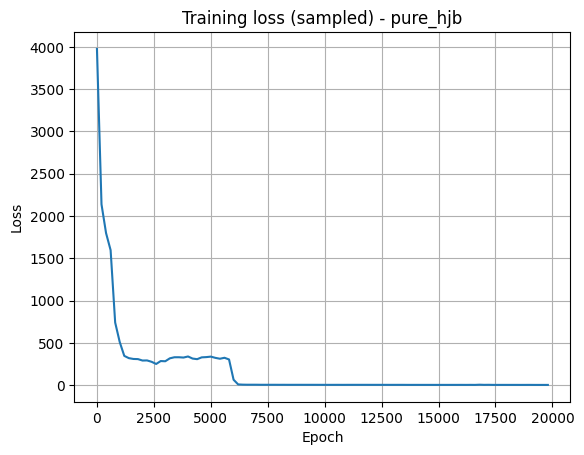

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


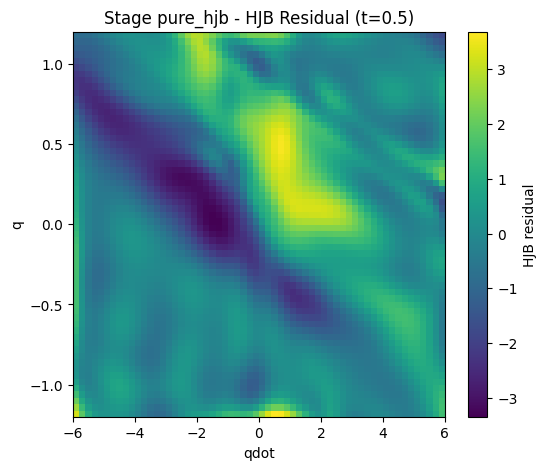

[rollout] max|q|=0.389 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1332 max_err=0.2886 peak_q=0.3886 peak_q_ref=0.5000 time_to_peak=0.7100 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=12.3995 rollout_peak_u_bounded=12.3995


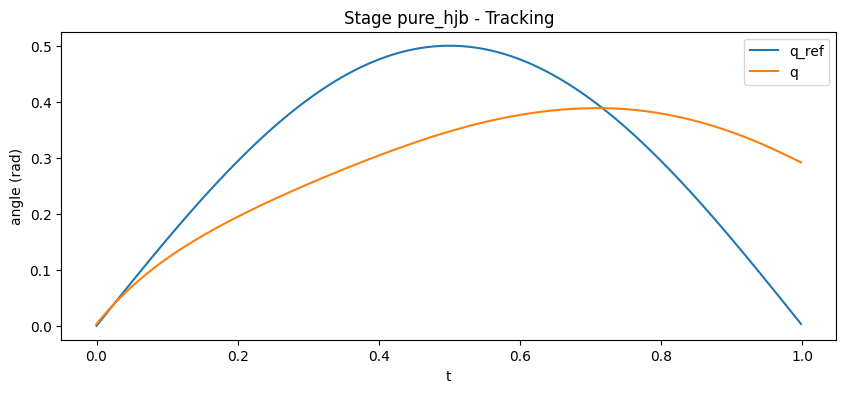

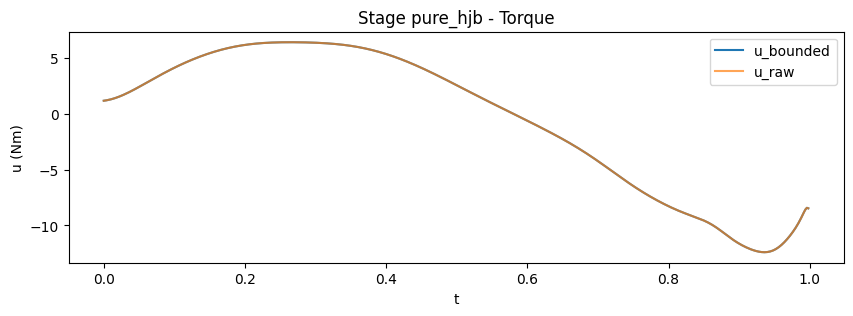

[compare] RMSE learned=0.1332 PD=0.1346 torque_corr=0.9947 torque_mae=0.2724 gain_ratio=0.9872
[compare] high_err_mean_u_learned=-0.3930 high_err_mean_u_pd=-0.4920


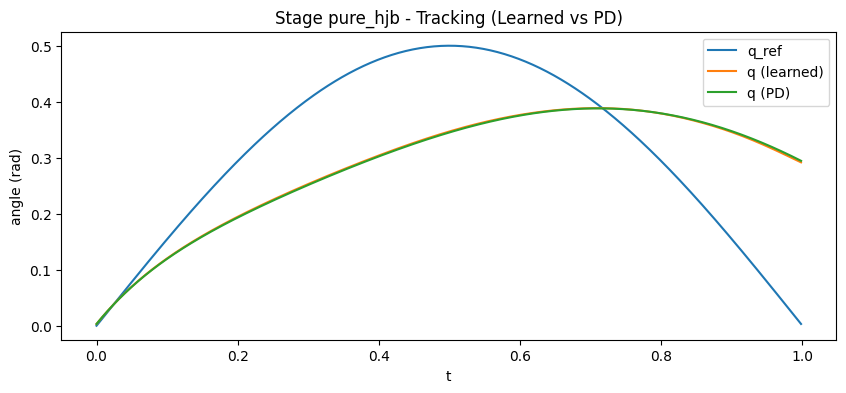

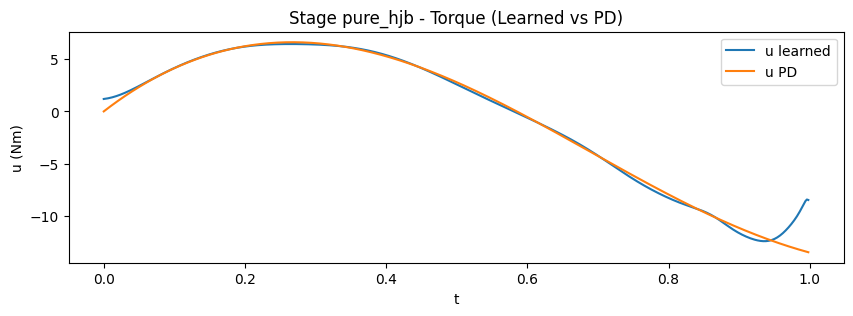

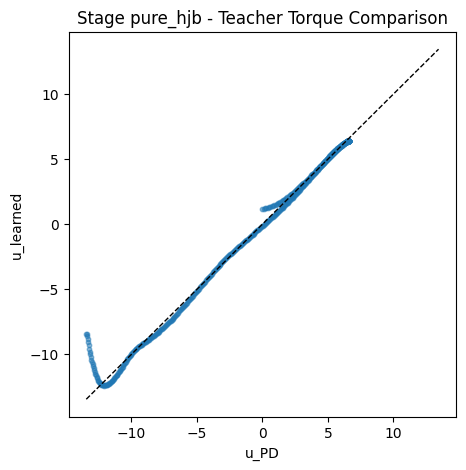

In [20]:
import copy

from src.baselines import pd_controller
from src.control_utils import apply_saturation, build_reference_functions, normalize_state
from src.hjb_pinn import sample_collocation


debug_cfg = cfg.get("debug", {})
DEBUG = bool(debug_cfg.get("enabled", True))

def dprint(*args, **kwargs):
    if DEBUG:
        print(*args, **kwargs)


def deep_update(target, src_dict):
    for k, v in src_dict.items():
        if isinstance(v, dict) and isinstance(target.get(k), dict):
            deep_update(target[k], v)
        else:
            target[k] = v


def build_residual_net(dyn_cfg_local):
    if not dyn_cfg_local or not dyn_cfg_local.get("use_residual", False):
        return None
    residual_net = ResidualNet().to(device)
    ckpt_path = ROOT / dyn_cfg_local.get("residual_ckpt", "")
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            residual_net.load_state_dict(ckpt["state_dict"])
        else:
            residual_net.load_state_dict(ckpt)
        dprint("Loaded residual net:", ckpt_path)
    else:
        dprint("Residual net checkpoint not found:", ckpt_path)
    residual_net.eval()
    for p in residual_net.parameters():
        p.requires_grad = False
    return residual_net


q_scale = max(abs(q_range[0]), abs(q_range[1]), 1e-6)
qd_scale = max(abs(qd_range[0]), abs(qd_range[1]), 1e-6)


def V_eval(net, q_in, qd_in, t_in):
    qn, qdn = normalize_state(q_in, qd_in, q_scale, qd_scale)
    return net(qn, qdn, t_in)


def V_eval_with_grads(net, q_in, qd_in, t_in, detach_state=True):
    # Default path preserves the original collocation behavior. `detach_state=False`
    # is used for differentiable rollout losses where gradients must flow through time.
    if detach_state:
        qn = (q_in / q_scale).detach().requires_grad_(True)
        qdn = (qd_in / qd_scale).detach().requires_grad_(True)
    else:
        qn = q_in / q_scale
        qdn = qd_in / qd_scale
        if not qn.requires_grad:
            qn = qn.requires_grad_(True)
        if not qdn.requires_grad:
            qdn = qdn.requires_grad_(True)
    t_var = t_in
    if not t_var.requires_grad:
        t_var = t_var.detach().requires_grad_(True)
    V = net(qn, qdn, t_var)
    V_t, V_qn, V_qdn = compute_grads(V, qn, qdn, t_var)
    V_q = V_qn / q_scale
    V_qd = V_qdn / qd_scale
    return V, V_t, V_q, V_qd


class LossBalancer:
    def __init__(self, beta=0.98, min_w=0.1, max_w=10.0, eps=1e-8):
        self.beta = beta
        self.min_w = min_w
        self.max_w = max_w
        self.eps = eps
        self.ema = {}

    def update(self, losses):
        for k, v in losses.items():
            val = float(v.detach().item())
            if k not in self.ema:
                self.ema[k] = val
            else:
                self.ema[k] = self.beta * self.ema[k] + (1.0 - self.beta) * val

    def weights(self):
        weights = {}
        for k, ema_v in self.ema.items():
            w = 1.0 / (ema_v + self.eps)
            w = max(self.min_w, min(self.max_w, w))
            weights[k] = w
        return weights


class BoundsTracker:
    def __init__(self):
        self.q_min = float("inf")
        self.q_max = float("-inf")
        self.qd_min = float("inf")
        self.qd_max = float("-inf")
        self.u_raw_min = float("inf")
        self.u_raw_max = float("-inf")
        self.u_bounded_min = float("inf")
        self.u_bounded_max = float("-inf")
        self.control_signal_min = float("inf")
        self.control_signal_max = float("-inf")

    def update(self, q=None, qd=None, u_raw=None, u_bounded=None, control_signal=None):
        if q is not None:
            qv = q.detach().cpu().numpy()
            self.q_min = min(self.q_min, float(qv.min()))
            self.q_max = max(self.q_max, float(qv.max()))
        if qd is not None:
            qdv = qd.detach().cpu().numpy()
            self.qd_min = min(self.qd_min, float(qdv.min()))
            self.qd_max = max(self.qd_max, float(qdv.max()))
        if u_raw is not None:
            uv = u_raw.detach().cpu().numpy()
            self.u_raw_min = min(self.u_raw_min, float(uv.min()))
            self.u_raw_max = max(self.u_raw_max, float(uv.max()))
        if u_bounded is not None:
            ubv = u_bounded.detach().cpu().numpy()
            self.u_bounded_min = min(self.u_bounded_min, float(ubv.min()))
            self.u_bounded_max = max(self.u_bounded_max, float(ubv.max()))
        if control_signal is not None:
            csv = control_signal.detach().cpu().numpy()
            self.control_signal_min = min(self.control_signal_min, float(csv.min()))
            self.control_signal_max = max(self.control_signal_max, float(csv.max()))


def _bounds_exceed_ratio(obs_min, obs_max, bound_min, bound_max):
    span = max(bound_max - bound_min, 1e-6)
    below = max(0.0, bound_min - obs_min) / span
    above = max(0.0, obs_max - bound_max) / span
    return max(below, above)


def compute_policy_control(
    net,
    q,
    qd,
    t,
    params,
    w_u,
    u_max,
    control_local,
    detach_state=True,
):
    use_tanh = bool(control_local.get("use_tanh_saturation", False))
    sat_method = "tanh" if use_tanh else "clamp"
    u_scale = float(control_local.get("u_scale", 1.0))
    cap_multiplier = bool(control_local.get("cap_multiplier", True))
    multiplier_cap = float(control_local.get("multiplier_cap", 1e3))
    _, _, _, V_qd = V_eval_with_grads(net, q, qd, t, detach_state=detach_state)
    u_raw, u_bounded = compute_control(
        V_qd,
        params,
        w_u,
        u_max=u_max,
        saturation_method=sat_method,
        u_scale=u_scale,
        cap_multiplier=cap_multiplier,
        multiplier_cap=multiplier_cap,
    )
    return u_raw, u_bounded, V_qd


def get_effective_loss_weights(stage_cfg, train_local, loss_cfg, epoch):
    final_weights = {
        "hjb": float(loss_cfg.get("w_hjb", 1.0)) * float(train_local.get("lambda_hjb", 1.0)),
        "term": float(loss_cfg.get("w_term", 10.0)) * float(train_local.get("lambda_term", 1.0)),
        "data": float(loss_cfg.get("w_data", 1.0)) * float(train_local.get("lambda_data", 0.0)),
        "traj": float(loss_cfg.get("w_traj", 0.0)) * float(train_local.get("lambda_traj", 0.0)),
        "sat": float(loss_cfg.get("w_sat", 1.0)) * float(train_local.get("lambda_sat", 0.0)),
        "u_mag": float(loss_cfg.get("w_u_mag", 0.0)),
        "box": float(loss_cfg.get("w_box", 0.0)),
        "rollout": float(loss_cfg.get("w_rollout", 0.0)) if bool(loss_cfg.get("use_rollout_loss", False)) else 0.0,
        "u_match": float(loss_cfg.get("w_u_match", 0.0)) if bool(loss_cfg.get("use_u_match", False)) else 0.0,
        "res_reg": float(train_local.get("lambda_res_reg", 0.0)),
    }

    schedule_cfg = stage_cfg.get("schedule", {})
    if bool(schedule_cfg.get("enable", False)):
        stage_a_epochs = int(schedule_cfg.get("stage_A_epochs", 3000))
        stage_b_epochs = int(schedule_cfg.get("stage_B_epochs", 3000))
        stage_a = schedule_cfg.get("stage_A", {})
        stage_b = schedule_cfg.get("stage_B", {})
        stage_c = schedule_cfg.get("stage_C", {})

        if epoch < stage_a_epochs:
            phase_name = "stage_A"
            weights = final_weights.copy()
            for key in weights:
                cfg_key = f"w_{key}"
                if cfg_key in stage_a:
                    weights[key] = float(stage_a[cfg_key])
            return phase_name, weights

        if epoch < stage_a_epochs + stage_b_epochs:
            phase_name = "stage_B"
            alpha = float(epoch - stage_a_epochs) / float(max(stage_b_epochs, 1))
            alpha = max(0.0, min(1.0, alpha))
            weights = final_weights.copy()
            for key in weights:
                cfg_key = f"w_{key}"
                if cfg_key in stage_b and key != "hjb":
                    weights[key] = float(stage_b[cfg_key])
            start_hjb = float(stage_a.get("w_hjb", 0.0))
            target_hjb = final_weights["hjb"]
            if "w_hjb" in stage_b:
                target_hjb = float(stage_b["w_hjb"])
            weights["hjb"] = (1.0 - alpha) * start_hjb + alpha * target_hjb
            return phase_name, weights

        phase_name = "stage_C"
        weights = final_weights.copy()
        if not bool(stage_c.get("use_final", True)):
            for key in weights:
                cfg_key = f"w_{key}"
                if cfg_key in stage_c:
                    weights[key] = float(stage_c[cfg_key])
        return phase_name, weights

    staged_cfg = train_local.get("staged", {})
    weights = final_weights.copy()
    if not bool(staged_cfg.get("enabled", False)):
        return "full", weights

    phase1_epochs = int(staged_cfg.get("phase1_epochs", 3000))
    phase2_epochs = int(staged_cfg.get("phase2_epochs", 5000))
    phase2_hjb_scale = float(staged_cfg.get("phase2_hjb_scale", 0.1))

    if epoch < phase1_epochs:
        weights["hjb"] = 0.0
        return "phase1", weights
    if epoch < phase1_epochs + phase2_epochs:
        weights["hjb"] *= phase2_hjb_scale
        return "phase2", weights
    return "phase3", weights


def pd_teacher_torque(q, qd, q_ref, qd_ref, cfg_local, u_max):
    base_cfg = cfg_local.get("baseline", {})
    kp = float(base_cfg.get("Kp", 30.0))
    kd = float(base_cfg.get("Kd", 5.0))
    u_pd = kp * (q_ref - q) + kd * (qd_ref - qd)
    return apply_saturation(u_pd, u_max, method="clamp")


def compute_teacher_metrics(
    t_sim,
    q_ref,
    xs,
    us_bounded,
    u_raws,
    xs_pd=None,
    us_pd=None,
    q_ref_pd=None,
    t_pd=None,
    error_threshold=0.1,
):
    n_learned = min(len(xs), len(q_ref))
    metrics = {
        "rmse_learned": float(np.sqrt(np.mean((xs[:n_learned, 0] - q_ref[:n_learned]) ** 2))) if n_learned > 0 else float("nan"),
        "rollout_peak_u_raw": float(np.max(np.abs(u_raws))) if len(u_raws) else 0.0,
        "rollout_peak_u_bounded": float(np.max(np.abs(us_bounded))) if len(us_bounded) else 0.0,
        "max_q_error": float(np.max(np.abs(xs[:n_learned, 0] - q_ref[:n_learned]))) if n_learned > 0 else float("nan"),
        "peak_q_learned": float(np.max(xs[:n_learned, 0])) if n_learned > 0 else float("nan"),
        "peak_q_ref": float(np.max(q_ref[:n_learned])) if n_learned > 0 else float("nan"),
    }
    if n_learned > 0:
        err = q_ref[:n_learned] - xs[:n_learned, 0]
        peak_idx = int(np.argmax(xs[:n_learned, 0]))
        ref_peak_idx = int(np.argmax(q_ref[:n_learned]))
        metrics["time_to_peak_learned"] = float(t_sim[min(peak_idx, len(t_sim) - 1)])
        metrics["time_to_peak_ref"] = float(t_sim[min(ref_peak_idx, len(t_sim) - 1)])
    else:
        err = np.array([])
        metrics["time_to_peak_learned"] = float("nan")
        metrics["time_to_peak_ref"] = float("nan")

    if xs_pd is not None and us_pd is not None and len(xs_pd) > 0:
        q_ref_pd = q_ref if q_ref_pd is None else q_ref_pd
        n_pd = min(len(xs_pd), len(q_ref_pd))
        t_pd = t_sim if t_pd is None else t_pd
        n = min(len(us_bounded), len(us_pd), n_learned, n_pd)
        metrics["rmse_pd"] = float(np.sqrt(np.mean((xs_pd[:n_pd, 0] - q_ref_pd[:n_pd]) ** 2))) if n_pd > 0 else float("nan")
        if n > 1 and np.std(us_bounded[:n]) > 1e-8 and np.std(us_pd[:n]) > 1e-8:
            metrics["torque_corr"] = float(np.corrcoef(us_bounded[:n], us_pd[:n])[0, 1])
        else:
            metrics["torque_corr"] = float("nan")
        metrics["torque_mae_pd"] = float(np.mean(np.abs(us_bounded[:n] - us_pd[:n]))) if n > 0 else float("nan")
        metrics["torque_gain_ratio"] = float(np.mean(np.abs(us_bounded[:n])) / max(np.mean(np.abs(us_pd[:n])), 1e-6)) if n > 0 else float("nan")
        high_err_mask = np.abs(err[:n]) > error_threshold if n > 0 else np.array([], dtype=bool)
        if np.any(high_err_mask):
            metrics["high_err_mean_u_learned"] = float(np.mean(us_bounded[:n][high_err_mask]))
            metrics["high_err_mean_u_pd"] = float(np.mean(us_pd[:n][high_err_mask]))
        else:
            metrics["high_err_mean_u_learned"] = float("nan")
            metrics["high_err_mean_u_pd"] = float("nan")
    return metrics


def compute_differentiable_rollout_losses(
    net,
    cfg_local,
    cfg_hjb,
    theta_ref_local,
    theta_ref_dot_local,
    u_max,
    residual_net,
    time_map,
):
    loss_cfg = cfg_local.get("loss", {})
    if not bool(loss_cfg.get("use_rollout_loss", False)):
        return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)

    rollout_horizon = float(loss_cfg.get("rollout_horizon", 0.25))
    rollout_batch = int(loss_cfg.get("rollout_batch", 16))
    rollout_steps = int(loss_cfg.get("rollout_steps", 20))
    rollout_steps = max(1, rollout_steps)

    control_local = cfg_local.get("control", {})
    dyn_local = cfg_local.get("dynamics", {})
    roll_cfg = cfg_local.get("rollout", {})
    integrator = str(roll_cfg.get("integrator", "rk4")).lower()
    residual_guard = bool(dyn_local.get("residual_guard", False))
    guard_theta_min = dyn_local.get("guard_theta_min")
    guard_theta_max = dyn_local.get("guard_theta_max")
    guard_omega_min = dyn_local.get("guard_omega_min")
    guard_omega_max = dyn_local.get("guard_omega_max")

    time_cfg = cfg_local.get("time", {})
    use_time_norm = bool(time_cfg.get("normalize", False))
    t_horizon = rollout_horizon / max(float(time_cfg.get("T_phys", 1.0)), 1e-6) if use_time_norm else rollout_horizon
    t0_max = max(float(t_range[1]) - t_horizon, float(t_range[0]))
    t0 = torch.rand(rollout_batch, 1, device=device) * max(t0_max - float(t_range[0]), 0.0) + float(t_range[0])
    x = torch.cat([theta_ref_local(time_map(t0)), theta_ref_dot_local(time_map(t0))], dim=1)

    dt_roll = t_horizon / float(rollout_steps)
    q_losses = []
    u_match_losses = []

    for step_idx in range(rollout_steps):
        t_curr = (t0 + step_idx * dt_roll).clone().detach().requires_grad_(True)
        q = x[:, 0:1]
        qd = x[:, 1:2]
        u_raw, u_bounded, _ = compute_policy_control(
            net,
            q,
            qd,
            t_curr,
            exo_params,
            cfg_hjb.w_u,
            u_max,
            control_local,
            detach_state=False,
        )
        theta_ref_t = theta_ref_local(time_map(t_curr))
        omega_ref_t = theta_ref_dot_local(time_map(t_curr))
        u_teacher = pd_teacher_torque(q, qd, theta_ref_t, omega_ref_t, cfg_local, u_max)

        def dynamics_step(x_in, t_in):
            q_in = x_in[:, 0:1]
            qd_in = x_in[:, 1:2]
            _, u_exec, _ = compute_policy_control(
                net,
                q_in,
                qd_in,
                t_in,
                exo_params,
                cfg_hjb.w_u,
                u_max,
                control_local,
                detach_state=False,
            )
            return knee_dynamics_torch(
                x_in,
                u_exec,
                exo_params,
                residual_net=residual_net,
                residual_guard=residual_guard,
                guard_theta_min=guard_theta_min,
                guard_theta_max=guard_theta_max,
                guard_omega_min=guard_omega_min,
                guard_omega_max=guard_omega_max,
            )

        if integrator == "rk4":
            k1 = dynamics_step(x, t_curr)
            k2 = dynamics_step(x + 0.5 * dt_roll * k1, t_curr + 0.5 * dt_roll)
            k3 = dynamics_step(x + 0.5 * dt_roll * k2, t_curr + 0.5 * dt_roll)
            k4 = dynamics_step(x + dt_roll * k3, t_curr + dt_roll)
            x = x + (dt_roll / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        else:
            x = x + dt_roll * dynamics_step(x, t_curr)

        t_next = t0 + (step_idx + 1) * dt_roll
        q_ref_next = theta_ref_local(time_map(t_next))
        q_losses.append((x[:, 0:1] - q_ref_next) ** 2)
        u_match_losses.append((u_bounded - u_teacher) ** 2)

    L_rollout = torch.cat(q_losses, dim=0).mean() if q_losses else torch.tensor(0.0, device=device)
    L_u_match = torch.cat(u_match_losses, dim=0).mean() if u_match_losses else torch.tensor(0.0, device=device)
    return L_rollout, L_u_match


def parameter_sanity_check(stage_cfg, u_max):
    I = float(exo_params.I)
    w_u = float(stage_cfg["cost_weights"]["w_u"])
    w_u_safe = max(w_u, 1e-12)
    mult = 1.0 / (2.0 * I * w_u_safe)
    control_local = stage_cfg.get("control", {})
    cap_multiplier = bool(control_local.get("cap_multiplier", False))
    multiplier_cap = float(control_local.get("multiplier_cap", 1e3))
    mult_used = mult
    capped = False
    if cap_multiplier and abs(mult) > multiplier_cap:
        mult_used = multiplier_cap if mult > 0 else -multiplier_cap
        capped = True
    qdd_max = abs(u_max / max(I, 1e-6))
    dprint(f"[params] I={I:.4f} B={float(exo_params.B):.4f} m={float(exo_params.m):.4f} "
           f"g={float(exo_params.g):.2f} l={float(exo_params.l):.4f} u_max={u_max:.2f}")
    dprint(f"[params] w_u={w_u:.6f} control_mult={mult:.3e} capped={capped} mult_used={mult_used:.3e}")
    dprint(f"[scales] q_scale={q_scale:.4f} qd_scale={qd_scale:.4f}")
    if qdd_max > 200.0:
        dprint(f"[params] WARNING: qdd_max?{qdd_max:.1f} rad/s^2 looks large; check I/u_max.")


def sanity_check_dynamics_and_sign(stage_cfg):
    run_sanity = bool(debug_cfg.get("run_sanity", debug_cfg.get("sanity", False)))
    if not run_sanity:
        return
    roll_cfg = stage_cfg.get("rollout", {})
    dt = float(roll_cfg.get("dt", 0.002))
    integrator = str(roll_cfg.get("integrator", "euler")).lower()
    u0 = 1.0

    def integrate(x0, u_const):
        x = x0.clone()
        steps = int(0.2 / dt)
        for _ in range(steps):
            if integrator == "rk4":
                k1 = knee_dynamics_torch(x, u_const, exo_params)
                k2 = knee_dynamics_torch(x + 0.5 * dt * k1, u_const, exo_params)
                k3 = knee_dynamics_torch(x + 0.5 * dt * k2, u_const, exo_params)
                k4 = knee_dynamics_torch(x + dt * k3, u_const, exo_params)
                x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
            else:
                x = x + dt * knee_dynamics_torch(x, u_const, exo_params)
        return x

    x0 = torch.tensor([[0.2, 0.0]], device=device)
    x_pos = integrate(x0, torch.tensor([u0], device=device))
    x_neg = integrate(x0, torch.tensor([-u0], device=device))

    dq_pos = float((x_pos[0, 0] - x0[0, 0]).detach().cpu())
    dq_neg = float((x_neg[0, 0] - x0[0, 0]).detach().cpu())
    dqd_pos = float((x_pos[0, 1] - x0[0, 1]).detach().cpu())
    dqd_neg = float((x_neg[0, 1] - x0[0, 1]).detach().cpu())

    dprint("[sanity] q0=0.2, qd0=0.0")
    dprint("[sanity] ?q(+u), ?qd(+u) =", dq_pos, dqd_pos)
    dprint("[sanity] ?q(-u), ?qd(-u) =", dq_neg, dqd_neg)
    if dq_pos > 0 and dq_neg < 0:
        dprint("[sanity] sign check ok: +u increases q, -u decreases q")
    else:
        dprint("[sanity] WARNING: sign mismatch suspected (torque/gravity sign?)")

    # PD micro-test on small amplitude reference
    control_local = stage_cfg.get("control", {})
    u_max = float(control_local.get("u_max", 20.0))
    kp = 30.0
    kd = 5.0
    steps = int(1.0 / dt)
    t = torch.linspace(0.0, 1.0, steps + 1, device=device)
    x = x0.clone()
    diverged = False
    for k in range(steps):
        q_ref = 0.1 * torch.sin(2 * np.pi * t[k])
        qd_ref = 0.1 * 2 * np.pi * torch.cos(2 * np.pi * t[k])
        u_pd = pd_controller(float(x[0, 0].item()), float(x[0, 1].item()), float(q_ref.item()), float(qd_ref.item()), kp, kd)
        u = apply_saturation(torch.tensor([u_pd], device=device), u_max, method="clamp")
        x = x + dt * knee_dynamics_torch(x, u, exo_params)
        if abs(float(x[0, 0].detach().cpu())) > max(3.0, q_range[1] * 2.0):
            diverged = True
            break

    if diverged:
        dprint("[sanity] PD micro-test diverged -> likely dynamics/ref/units issue")
    else:
        dprint("[sanity] PD micro-test stable on 0.1 rad sinusoid")


def _time_mapper(cfg_local):
    time_cfg = cfg_local.get("time", {})
    use_norm = bool(time_cfg.get("normalize", False))
    T_phys = float(time_cfg.get("T_phys", 1.0))

    def map_time(t_tensor):
        return t_tensor * T_phys if use_norm else t_tensor

    return map_time, use_norm, T_phys


def build_reference(cfg_local):
    ref_type = str(cfg_local.get("reference", {}).get("type", "synthetic")).lower()
    if ref_type in {"epic_mean", "siat_cycle"}:
        if not use_epic or epic_samples is None:
            dprint(f"Requested reference.type={ref_type}, but EPIC data not available. Falling back to synthetic.")
            return build_reference_functions(cfg_local)
        theta_mat = np.stack([s.theta for s in epic_samples])
        theta_ref_arr = theta_mat.mean(axis=0)
        t_ref = epic_samples[0].t
        return build_reference_functions(cfg_local, t_ref=t_ref, theta_ref_arr=theta_ref_arr)
    return build_reference_functions(cfg_local)


def plot_hjb_residual(net, cfg_local, cfg_hjb, theta_ref_local, theta_ref_dot_local, u_max, residual_net, title):
    control_local = cfg_local.get("control", {})
    hjb_cfg = cfg_local.get("hjb", {})
    use_saturated_hjb = bool(hjb_cfg.get("use_u_bounded_in_residual", control_local.get("use_saturated_hjb", True)))
    use_tanh = bool(control_local.get("use_tanh_saturation", False))
    sat_method = "tanh" if use_tanh else "clamp"
    u_scale = float(control_local.get("u_scale", 1.0))
    cap_multiplier = bool(control_local.get("cap_multiplier", True))
    multiplier_cap = float(control_local.get("multiplier_cap", 1e3))
    dyn_local = cfg_local.get("dynamics", {})
    residual_guard = bool(dyn_local.get("residual_guard", False))
    guard_theta_min = dyn_local.get("guard_theta_min")
    guard_theta_max = dyn_local.get("guard_theta_max")
    guard_omega_min = dyn_local.get("guard_omega_min")
    guard_omega_max = dyn_local.get("guard_omega_max")
    n = 60
    q_lin = torch.linspace(q_range[0], q_range[1], n, device=device).reshape(-1, 1)
    qd_lin = torch.linspace(qd_range[0], qd_range[1], n, device=device).reshape(-1, 1)
    qq, qdqd = torch.meshgrid(q_lin.squeeze(), qd_lin.squeeze(), indexing="ij")
    qq = qq.reshape(-1, 1).requires_grad_(True)
    qdqd = qdqd.reshape(-1, 1).requires_grad_(True)
    t_mid_val = 0.5 * (t_range[0] + t_range[1])
    t_mid = torch.full_like(qq, t_mid_val, requires_grad=True)

    map_time, _, _ = _time_mapper(cfg_local)

    V, V_t, V_q, V_qd = V_eval_with_grads(net, qq, qdqd, t_mid)
    theta_ref_t = theta_ref_local(map_time(t_mid))
    omega_ref_t = theta_ref_dot_local(map_time(t_mid))
    residual = hjb_residual(
        qq,
        qdqd,
        t_mid,
        V,
        V_t,
        V_q,
        V_qd,
        exo_params,
        cfg_hjb,
        theta_ref_t,
        omega_ref_t,
        u_max=u_max,
        use_saturated_hjb=use_saturated_hjb,
        saturation_method=sat_method,
        u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
        residual_net=residual_net,
        residual_guard=residual_guard,
        guard_theta_min=guard_theta_min,
        guard_theta_max=guard_theta_max,
        guard_omega_min=guard_omega_min,
        guard_omega_max=guard_omega_max,
    )
    res_grid = residual.detach().cpu().numpy().reshape(n, n)

    plt.figure(figsize=(6, 5))
    plt.imshow(
        res_grid,
        extent=[qd_range[0], qd_range[1], q_range[0], q_range[1]],
        origin="lower",
        aspect="auto",
    )
    plt.colorbar(label="HJB residual")
    plt.xlabel("qdot")
    plt.ylabel("q")
    plt.title(f"{title} - HJB Residual (t=0.5)")
    plt.show()


def _oob_check(x, eps=0.0):
    q = x[:, 0]
    qd = x[:, 1]
    oob = (
        (q < q_range[0] - eps)
        | (q > q_range[1] + eps)
        | (qd < qd_range[0] - eps)
        | (qd > qd_range[1] + eps)
    )
    return bool(oob.any())


def simulate_policy(net, cfg_local, cfg_hjb, theta_ref_local, theta_ref_dot_local, u_max, residual_net, T=1.0):
    roll_cfg = cfg_local.get("rollout", {})
    dt = float(roll_cfg.get("dt", 0.002))
    integrator = str(roll_cfg.get("integrator", "euler")).lower()
    stop_on_oob = bool(roll_cfg.get("stop_on_oob", True))
    clamp_on_oob = bool(roll_cfg.get("clamp_on_oob", False))
    oob_eps = float(roll_cfg.get("oob_epsilon", 0.0))

    time_map, use_time_norm, T_phys = _time_mapper(cfg_local)
    if use_time_norm:
        dt = dt / max(T_phys, 1e-6)

    control_local = cfg_local.get("control", {})
    use_tanh = bool(control_local.get("use_tanh_saturation", False))
    sat_method = "tanh" if use_tanh else "clamp"
    u_scale = float(control_local.get("u_scale", 1.0))
    cap_multiplier = bool(control_local.get("cap_multiplier", True))
    multiplier_cap = float(control_local.get("multiplier_cap", 1e3))

    dyn_local = cfg_local.get("dynamics", {})
    residual_guard = bool(dyn_local.get("residual_guard", False))
    guard_theta_min = dyn_local.get("guard_theta_min")
    guard_theta_max = dyn_local.get("guard_theta_max")
    guard_omega_min = dyn_local.get("guard_omega_min")
    guard_omega_max = dyn_local.get("guard_omega_max")

    steps = int(T / dt)
    t = np.linspace(0.0, T, steps + 1, dtype=np.float32)
    q0 = theta_ref_local(time_map(torch.tensor([[0.0]], device=device))).detach()
    qd0 = theta_ref_dot_local(time_map(torch.tensor([[0.0]], device=device))).detach()
    x = torch.cat([q0, qd0], dim=1).to(device).requires_grad_(True)

    xs = []
    us = []
    u_raws = []
    oob_hit = None

    for k in range(steps):
        tt = torch.tensor([[t[k]]], device=device, dtype=torch.float32, requires_grad=True)

        def policy(x_in, t_in):
            q = x_in[:, 0:1]
            qd = x_in[:, 1:2]
            _, _, _, V_qd = V_eval_with_grads(net, q, qd, t_in)
            u_raw, u_bounded = compute_control(
                V_qd,
                exo_params,
                cfg_hjb.w_u,
                u_max=u_max,
                saturation_method=sat_method,
                u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
            )
            return u_raw, u_bounded

        def f(x_in, t_in):
            _, u = policy(x_in, t_in)
            return knee_dynamics_torch(
                x_in,
                u,
                exo_params,
                residual_net=residual_net,
                residual_guard=residual_guard,
                guard_theta_min=guard_theta_min,
                guard_theta_max=guard_theta_max,
                guard_omega_min=guard_omega_min,
                guard_omega_max=guard_omega_max,
            )

        if integrator == "rk4":
            k1 = f(x, tt)
            k2 = f(x + 0.5 * dt * k1, tt + 0.5 * dt)
            k3 = f(x + 0.5 * dt * k2, tt + 0.5 * dt)
            k4 = f(x + dt * k3, tt + dt)
            x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        else:
            x = x + dt * f(x, tt)

        u_raw_now, u_now = policy(x, tt)
        if oob_hit is None and _oob_check(x, eps=oob_eps):
            oob_hit = k
            dprint(f"[rollout] OOB at step {k}, t={t[k]:.4f}")
            if clamp_on_oob:
                x[:, 0] = x[:, 0].clamp(q_range[0], q_range[1])
                x[:, 1] = x[:, 1].clamp(qd_range[0], qd_range[1])
            if stop_on_oob:
                x = x.detach().requires_grad_(True)
                break

        x = x.detach().requires_grad_(True)
        xs.append(x.detach().cpu().numpy()[0])
        us.append(float(u_now.detach().cpu().numpy().squeeze()))
        u_raws.append(float(u_raw_now.detach().cpu().numpy().squeeze()))

    q_ref = theta_ref_local(time_map(torch.tensor(t[: len(xs)], dtype=torch.float32, device=device).reshape(-1, 1)))
    q_ref = q_ref.detach().cpu().numpy().reshape(-1)
    return t[: len(xs)], np.array(xs), np.array(us).reshape(-1), np.array(u_raws).reshape(-1), q_ref, oob_hit


def simulate_pd(cfg_local, theta_ref_local, theta_ref_dot_local, u_max, residual_net, T=1.0):
    roll_cfg = cfg_local.get("rollout", {})
    dt = float(roll_cfg.get("dt", 0.002))
    integrator = str(roll_cfg.get("integrator", "euler")).lower()
    stop_on_oob = bool(roll_cfg.get("stop_on_oob", True))
    clamp_on_oob = bool(roll_cfg.get("clamp_on_oob", False))
    oob_eps = float(roll_cfg.get("oob_epsilon", 0.0))

    base_cfg = cfg_local.get("baseline", {})
    kp = float(base_cfg.get("Kp", 30.0))
    kd = float(base_cfg.get("Kd", 5.0))

    time_map, use_time_norm, T_phys = _time_mapper(cfg_local)
    if use_time_norm:
        dt = dt / max(T_phys, 1e-6)

    dyn_local = cfg_local.get("dynamics", {})
    residual_guard = bool(dyn_local.get("residual_guard", False))
    guard_theta_min = dyn_local.get("guard_theta_min")
    guard_theta_max = dyn_local.get("guard_theta_max")
    guard_omega_min = dyn_local.get("guard_omega_min")
    guard_omega_max = dyn_local.get("guard_omega_max")

    steps = int(T / dt)
    t = np.linspace(0.0, T, steps + 1, dtype=np.float32)
    q0 = theta_ref_local(time_map(torch.tensor([[0.0]], device=device))).detach()
    qd0 = theta_ref_dot_local(time_map(torch.tensor([[0.0]], device=device))).detach()
    x = torch.cat([q0, qd0], dim=1).to(device)

    xs = []
    us = []
    oob_hit = None

    for k in range(steps):
        tt = torch.tensor([[t[k]]], device=device, dtype=torch.float32)
        q_ref = theta_ref_local(time_map(tt))
        qd_ref = theta_ref_dot_local(time_map(tt))
        u_pd = pd_controller(
            float(x[:, 0].item()),
            float(x[:, 1].item()),
            float(q_ref.item()),
            float(qd_ref.item()),
            kp,
            kd,
        )
        u = apply_saturation(torch.tensor([u_pd], device=device), u_max, method="clamp")

        if integrator == "rk4":
            k1 = knee_dynamics_torch(x, u, exo_params, residual_net=residual_net, residual_guard=residual_guard,
                                     guard_theta_min=guard_theta_min, guard_theta_max=guard_theta_max,
                                     guard_omega_min=guard_omega_min, guard_omega_max=guard_omega_max)
            k2 = knee_dynamics_torch(x + 0.5 * dt * k1, u, exo_params, residual_net=residual_net, residual_guard=residual_guard,
                                     guard_theta_min=guard_theta_min, guard_theta_max=guard_theta_max,
                                     guard_omega_min=guard_omega_min, guard_omega_max=guard_omega_max)
            k3 = knee_dynamics_torch(x + 0.5 * dt * k2, u, exo_params, residual_net=residual_net, residual_guard=residual_guard,
                                     guard_theta_min=guard_theta_min, guard_theta_max=guard_theta_max,
                                     guard_omega_min=guard_omega_min, guard_omega_max=guard_omega_max)
            k4 = knee_dynamics_torch(x + dt * k3, u, exo_params, residual_net=residual_net, residual_guard=residual_guard,
                                     guard_theta_min=guard_theta_min, guard_theta_max=guard_theta_max,
                                     guard_omega_min=guard_omega_min, guard_omega_max=guard_omega_max)
            x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        else:
            x = x + dt * knee_dynamics_torch(
                x,
                u,
                exo_params,
                residual_net=residual_net,
                residual_guard=residual_guard,
                guard_theta_min=guard_theta_min,
                guard_theta_max=guard_theta_max,
                guard_omega_min=guard_omega_min,
                guard_omega_max=guard_omega_max,
            )

        if oob_hit is None and _oob_check(x, eps=oob_eps):
            oob_hit = k
            dprint(f"[pd] OOB at step {k}, t={t[k]:.4f}")
            if clamp_on_oob:
                x[:, 0] = x[:, 0].clamp(q_range[0], q_range[1])
                x[:, 1] = x[:, 1].clamp(qd_range[0], qd_range[1])
            if stop_on_oob:
                break

        xs.append(x.detach().cpu().numpy()[0])
        us.append(float(u.detach().cpu().numpy().squeeze()))

    q_ref = theta_ref_local(time_map(torch.tensor(t[: len(xs)], dtype=torch.float32, device=device).reshape(-1, 1)))
    q_ref = q_ref.detach().cpu().numpy().reshape(-1)
    return t[: len(xs)], np.array(xs), np.array(us).reshape(-1), q_ref, oob_hit


def evaluate_stage(net, cfg_local, residual_net, stage_name, make_plots=True):
    weights_local = cfg_local["cost_weights"]
    train_local = cfg_local["training"]
    control_local = cfg_local.get("control", {})
    u_max = float(control_local.get("u_max", train_local.get("u_max", 20.0)))

    cfg_hjb = HJBConfig(
        w_track=float(weights_local["w_track"]),
        w_omega=float(weights_local["w_omega"]),
        w_u=float(weights_local["w_u"]),
    )

    theta_ref_local, theta_ref_dot_local = build_reference(cfg_local)

    if make_plots:
        plot_hjb_residual(
            net,
            cfg_local,
            cfg_hjb,
            theta_ref_local,
            theta_ref_dot_local,
            u_max,
            residual_net,
            title=f"Stage {stage_name}",
        )

    t_sim, xs, us, u_raws, q_ref, oob_hit = simulate_policy(
        net,
        cfg_local,
        cfg_hjb,
        theta_ref_local,
        theta_ref_dot_local,
        u_max,
        residual_net,
        T=T,
    )

    max_q = float(np.max(np.abs(xs[:, 0])))
    max_dq = float(np.max(np.abs(xs[:, 1])))
    nan_flag = bool(np.isnan(xs).any() or np.isnan(us).any())
    dprint(f"[rollout] max|q|={max_q:.3f} max|dq|={max_dq:.3f} nan={nan_flag} oob={oob_hit}")

    error_threshold = float(cfg_local.get("loss", {}).get("torque_error_threshold", 0.1))
    metrics = compute_teacher_metrics(t_sim, q_ref, xs, us, u_raws, error_threshold=error_threshold)
    metrics["oob_step_learned"] = oob_hit
    dprint(
        f"[tracking] rmse={metrics['rmse_learned']:.4f} max_err={metrics['max_q_error']:.4f} "
        f"peak_q={metrics['peak_q_learned']:.4f} peak_q_ref={metrics['peak_q_ref']:.4f} "
        f"time_to_peak={metrics['time_to_peak_learned']:.4f} time_to_peak_ref={metrics['time_to_peak_ref']:.4f}"
    )
    dprint(
        f"[rollout] rollout_peak_u_raw={metrics['rollout_peak_u_raw']:.4f} "
        f"rollout_peak_u_bounded={metrics['rollout_peak_u_bounded']:.4f}"
    )

    if make_plots:
        plt.figure(figsize=(10, 4))
        plt.plot(t_sim, q_ref, label="q_ref")
        plt.plot(t_sim, xs[:, 0], label="q")
        plt.title(f"Stage {stage_name} - Tracking")
        plt.xlabel("t")
        plt.ylabel("angle (rad)")
        plt.legend()
        plt.grid(False)
        plt.show()

        plt.figure(figsize=(10, 3))
        plt.plot(t_sim, us, label="u_bounded")
        plt.plot(t_sim, u_raws, label="u_raw", alpha=0.7)
        plt.title(f"Stage {stage_name} - Torque")
        plt.xlabel("t")
        plt.ylabel("u (Nm)")
        plt.legend()
        plt.grid(False)
        plt.show()

    base_cfg = cfg_local.get("baseline", {})
    if bool(base_cfg.get("enable_pd", True)):
        t_pd, xs_pd, us_pd, q_ref_pd, oob_pd = simulate_pd(
            cfg_local,
            theta_ref_local,
            theta_ref_dot_local,
            u_max,
            residual_net,
            T=T,
        )
        metrics.update(
            compute_teacher_metrics(
                t_sim,
                q_ref,
                xs,
                us,
                u_raws,
                xs_pd=xs_pd,
                us_pd=us_pd,
                q_ref_pd=q_ref_pd,
                t_pd=t_pd,
                error_threshold=error_threshold,
            )
        )
        metrics["oob_step_pd"] = oob_pd
        dprint(
            f"[compare] RMSE learned={metrics['rmse_learned']:.4f} PD={metrics['rmse_pd']:.4f} "
            f"torque_corr={metrics['torque_corr']:.4f} torque_mae={metrics['torque_mae_pd']:.4f} "
            f"gain_ratio={metrics['torque_gain_ratio']:.4f}"
        )
        dprint(
            f"[compare] high_err_mean_u_learned={metrics.get('high_err_mean_u_learned', float('nan')):.4f} "
            f"high_err_mean_u_pd={metrics.get('high_err_mean_u_pd', float('nan')):.4f}"
        )
        if metrics["rmse_learned"] > metrics["rmse_pd"] and np.isfinite(metrics["torque_corr"]) and metrics["torque_corr"] < 0.6:
            dprint("[compare] Learned torque shape differs from PD while PD tracks better -> likely objective mismatch.")
        if oob_pd is not None and oob_hit is not None:
            dprint("[compare] PD and learned both hit OOB -> likely dynamics/ref/units issue")
        elif oob_pd is None and oob_hit is not None:
            dprint("[compare] PD stable but learned diverged -> likely learning setup issue")

        if make_plots and bool(base_cfg.get("compare_plots", True)):
            plt.figure(figsize=(10, 4))
            plt.plot(t_sim, q_ref, label="q_ref")
            plt.plot(t_sim, xs[:, 0], label="q (learned)")
            plt.plot(t_pd, xs_pd[:, 0], label="q (PD)")
            plt.title(f"Stage {stage_name} - Tracking (Learned vs PD)")
            plt.xlabel("t")
            plt.ylabel("angle (rad)")
            plt.legend()
            plt.grid(False)
            plt.show()

            plt.figure(figsize=(10, 3))
            plt.plot(t_sim, us, label="u learned")
            plt.plot(t_pd, us_pd, label="u PD")
            plt.title(f"Stage {stage_name} - Torque (Learned vs PD)")
            plt.xlabel("t")
            plt.ylabel("u (Nm)")
            plt.legend()
            plt.grid(False)
            plt.show()

            n = min(len(us), len(us_pd))
            plt.figure(figsize=(5, 5))
            plt.scatter(us_pd[:n], us[:n], s=10, alpha=0.5)
            lim = max(float(np.max(np.abs(us_pd[:n]))), float(np.max(np.abs(us[:n]))), 1.0)
            plt.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1)
            plt.xlabel("u_PD")
            plt.ylabel("u_learned")
            plt.title(f"Stage {stage_name} - Teacher Torque Comparison")
            plt.grid(False)
            plt.show()

    return metrics

def train_stage(stage_name, overrides=None, init_ckpt=None, cfg_override=None):
    stage_cfg = copy.deepcopy(cfg)
    if cfg_override:
        deep_update(stage_cfg, cfg_override)
    stage_cfg["training"]["mode"] = stage_name
    if overrides:
        stage_cfg["training"].update(overrides)

    train_local = stage_cfg["training"]
    weights_local = stage_cfg["cost_weights"]
    control_local = stage_cfg.get("control", {})
    dyn_local = stage_cfg.get("dynamics", {})
    roll_cfg = stage_cfg.get("rollout", {})
    loss_cfg = stage_cfg.get("loss", {})
    normalize_per_batch = bool(loss_cfg.get("normalize_per_batch", True))

    def reduce_loss(x):
        return x.mean() if normalize_per_batch else x.sum()

    state_cfg = stage_cfg.get("state_reg", {})
    sample_cfg = stage_cfg.get("sample", {})
    hjb_cfg = stage_cfg.get("hjb", {})
    report_objective = bool(debug_cfg.get("report_objective", True))

    use_saturated_hjb = bool(hjb_cfg.get("use_u_bounded_in_residual", control_local.get("use_saturated_hjb", True)))
    use_tanh = bool(control_local.get("use_tanh_saturation", False))
    sat_method = "tanh" if use_tanh else "clamp"
    u_scale = float(control_local.get("u_scale", 1.0))
    cap_multiplier = bool(control_local.get("cap_multiplier", True))
    multiplier_cap = float(control_local.get("multiplier_cap", 1e3))

    residual_guard = bool(dyn_local.get("residual_guard", False))
    guard_theta_min = dyn_local.get("guard_theta_min")
    guard_theta_max = dyn_local.get("guard_theta_max")
    guard_omega_min = dyn_local.get("guard_omega_min")
    guard_omega_max = dyn_local.get("guard_omega_max")

    cfg_hjb = HJBConfig(
        w_track=float(weights_local["w_track"]),
        w_omega=float(weights_local["w_omega"]),
        w_u=float(weights_local["w_u"]),
    )

    u_max = float(control_local.get("u_max", train_local.get("u_max", 20.0)))
    theta_ref_local, theta_ref_dot_local = build_reference(stage_cfg)

    residual_net = build_residual_net(dyn_local)

    if init_ckpt is None:
        candidate = None
        if stage_name == "hjb_data":
            candidate = ROOT / "checkpoints" / "hjb_pinn_knee_pure_hjb.pt"
        elif stage_name == "hjb_data_traj":
            candidate = ROOT / "checkpoints" / "hjb_pinn_knee_hjb_data.pt"
        if candidate is not None and candidate.exists():
            init_ckpt = candidate
            dprint("Auto-loading init checkpoint:", init_ckpt)

    net = ValueNet(
        hidden_layers=int(model["hidden_layers"]),
        hidden_units=int(model["hidden_units"]),
        activation=str(model["activation"]),
    ).to(device)

    if init_ckpt is not None and Path(init_ckpt).exists():
        ckpt = torch.load(init_ckpt, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            net.load_state_dict(ckpt["state_dict"])
        else:
            net.load_state_dict(ckpt)
        dprint("Loaded init checkpoint:", init_ckpt)

    optimizer = torch.optim.Adam(net.parameters(), lr=float(train_local["lr"]))

    def sample_collocation_tensors():
        num_collocation = int(train_local.get("num_collocation", 15000))
        xyz, info = sample_collocation(stage_cfg, num_collocation, return_info=True)
        q = torch.tensor(xyz[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        qd = torch.tensor(xyz[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)
        t = torch.tensor(xyz[:, 2:3], dtype=torch.float32, device=device, requires_grad=True)
        return q, qd, t, info

    q, qd, t, colloc_info = sample_collocation_tensors()

    if colloc_info.get("clipped_ratio", 0.0) > 0.0:
        dprint(f"[sample] clipped_ratio={colloc_info['clipped_ratio']:.3f} oob_by_dim={colloc_info['oob_by_dim']}")

    num_terminal = int(train_local.get("num_terminal", 2000))
    qT = torch.tensor(np.random.uniform(q_range[0], q_range[1], size=(num_terminal, 1)).astype(np.float32), device=device, requires_grad=True)
    qdT = torch.tensor(np.random.uniform(qd_range[0], qd_range[1], size=(num_terminal, 1)).astype(np.float32), device=device, requires_grad=True)
    tT = torch.full_like(qT, t_range[1], device=device, requires_grad=True)

    log_every = int(debug_cfg.get("log_every", train_local.get("log_every", 200)))
    log_every = max(log_every, 200)

    grad_clip = float(train_local.get("grad_clip", 0.0))
    grad_ema_beta = float(train_local.get("grad_ema_beta", 0.98))
    grad_ema = None

    adaptive_weights = bool(loss_cfg.get("adaptive_weights", False))
    balancer = None
    if adaptive_weights:
        balancer = LossBalancer(
            beta=float(loss_cfg.get("ema_beta", 0.98)),
            min_w=float(loss_cfg.get("adaptive_clip_min", 0.1)),
            max_w=float(loss_cfg.get("adaptive_clip_max", 10.0)),
        )

    loss_hist = []
    hist = {
        "epoch": [],
        "phase": [],
        "L_hjb": [],
        "L_term": [],
        "L_data": [],
        "L_traj": [],
        "L_rollout": [],
        "L_u_match": [],
        "L_sat": [],
        "L_u_mag": [],
        "L_box": [],
        "L_total": [],
    }

    debug_every = int(roll_cfg.get("debug_every", 0))
    debug_dir = Path(roll_cfg.get("output_dir", "debug_outputs"))
    if debug_every > 0:
        debug_dir.mkdir(parents=True, exist_ok=True)

    parameter_sanity_check(stage_cfg, u_max)
    sanity_check_dynamics_and_sign(stage_cfg)

    time_map, use_time_norm, T_phys = _time_mapper(stage_cfg)
    dprint("TRAIN/ROLLOUT CONSISTENCY CHECK")
    dprint(f"  dt={float(roll_cfg.get('dt', 0.002))} horizon={T} time_normalized={use_time_norm} T_phys={T_phys}")
    dprint(f"  u_max={u_max} sat_method={sat_method} ref_type={stage_cfg.get('reference', {}).get('type', 'synthetic')}")

    printed_data_debug = False
    objective_reported = False
    last_phase_name = None
    range_tracker = BoundsTracker()
    auto_expand_tracker = BoundsTracker() if bool(sample_cfg.get("auto_expand_report", False)) else None

    for epoch in tqdm(range(int(train_local["epochs"])), desc=f"Training {stage_name}"):
        optimizer.zero_grad()
        V, V_t, V_q, V_qd = V_eval_with_grads(net, q, qd, t)

        phase_name, resolved_weights = get_effective_loss_weights(stage_cfg, train_local, loss_cfg, epoch)
        if phase_name != last_phase_name:
            dprint(f"[schedule] entering {phase_name} at epoch {epoch}")
            last_phase_name = phase_name

        theta_ref_t = theta_ref_local(time_map(t))
        omega_ref_t = theta_ref_dot_local(time_map(t))
        residual = hjb_residual(
            q,
            qd,
            t,
            V,
            V_t,
            V_q,
            V_qd,
            exo_params,
            cfg_hjb,
            theta_ref_t,
            omega_ref_t,
            u_max=u_max,
            use_saturated_hjb=use_saturated_hjb,
            saturation_method=sat_method,
            u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
            residual_net=residual_net,
            residual_guard=residual_guard,
            guard_theta_min=guard_theta_min,
            guard_theta_max=guard_theta_max,
            guard_omega_min=guard_omega_min,
            guard_omega_max=guard_omega_max,
        )
        L_hjb = reduce_loss(residual ** 2)

        V_T = V_eval(net, qT, qdT, tT)
        theta_ref_T = theta_ref_local(time_map(tT))
        omega_ref_T = theta_ref_dot_local(time_map(tT))
        qf_theta = float(loss_cfg.get("qf_theta", 10.0))
        qf_omega = float(loss_cfg.get("qf_omega", 1.0))
        V_T_target = qf_theta * (qT - theta_ref_T) ** 2 + qf_omega * (qdT - omega_ref_T) ** 2
        L_term = reduce_loss((V_T - V_T_target) ** 2)

        u_raw, u_bounded = compute_control(
            V_qd,
            exo_params,
            cfg_hjb.w_u,
            u_max=u_max,
            saturation_method=sat_method,
            u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
        )
        if use_tanh:
            L_sat = reduce_loss(u_raw ** 2)
        else:
            L_sat = reduce_loss((u_bounded - u_raw) ** 2)
        L_u_mag = reduce_loss(u_raw ** 2)
        u_used = u_bounded if use_saturated_hjb else u_raw
        track_term = cfg_hjb.w_track * (q - theta_ref_t) ** 2
        omega_term = cfg_hjb.w_omega * (qd - omega_ref_t) ** 2
        control_term = cfg_hjb.w_u * (u_used ** 2)
        control_signal = V_qd * qd_scale
        sat_ratio = (u_raw.abs() > u_max).float().mean()
        u_clip_min = float(u_bounded.min().detach().cpu().numpy())
        u_clip_max = float(u_bounded.max().detach().cpu().numpy())

        if report_objective and not objective_reported:
            objective_reported = True
            dprint("[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2")
            dprint(
                f"[objective] w_track={cfg_hjb.w_track:.4f} w_omega={cfg_hjb.w_omega:.4f} w_u={cfg_hjb.w_u:.4f} "
                f"use_u_bounded_in_residual={use_saturated_hjb}"
            )
            dprint(
                f"[objective] mean terms track={float(track_term.mean().detach().cpu()):.4f} "
                f"omega={float(omega_term.mean().detach().cpu()):.4f} "
                f"control={float(control_term.mean().detach().cpu()):.4f}"
            )

        L_box = torch.tensor(0.0, device=device)
        if bool(state_cfg.get("enabled", False)):
            q_max = float(state_cfg.get("q_max", 2.5))
            dq_max = float(state_cfg.get("dq_max", 8.0))
            L_box = reduce_loss(
                torch.relu(q.abs() - q_max) ** 2
                + torch.relu(qd.abs() - dq_max) ** 2
            )

        L_data = torch.tensor(0.0, device=device)
        if use_siat:
            idx = np.random.randint(0, len(siat_theta), size=2048)
            q_s = torch.tensor(siat_theta[idx][:, None], dtype=torch.float32, device=device, requires_grad=True)
            qd_s = torch.tensor(siat_omega[idx][:, None], dtype=torch.float32, device=device, requires_grad=True)
            t_s = torch.tensor(siat_t[idx][:, None], dtype=torch.float32, device=device, requires_grad=True)
            u_s = torch.tensor(siat_u[idx][:, None], dtype=torch.float32, device=device)

            _, _, _, V_qd_s = V_eval_with_grads(net, q_s, qd_s, t_s)
            _, u_clipped_s = compute_control(
                V_qd_s,
                exo_params,
                cfg_hjb.w_u,
                u_max=u_max,
                saturation_method=sat_method,
                u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
            )
            L_data = reduce_loss((u_clipped_s - u_s) ** 2)

            if not printed_data_debug:
                printed_data_debug = True
                q_ref_s = theta_ref_local(time_map(t_s)).detach().cpu().numpy().reshape(-1)
                dprint("[data debug] q min/max", float(q_s.min().detach()), float(q_s.max().detach()))
                dprint("[data debug] q_ref min/max", float(q_ref_s.min()), float(q_ref_s.max()))
                dprint("[data debug] qd min/max", float(qd_s.min().detach()), float(qd_s.max().detach()))
                dprint("[data debug] u min/max", float(u_s.min().detach()), float(u_s.max().detach()))
                dprint("[data debug] t min/max", float(t_s.min().detach()), float(t_s.max().detach()))

        L_traj = torch.tensor(0.0, device=device)
        if resolved_weights.get("traj", 0.0) > 0.0 or float(train_local.get("lambda_traj", 0.0)) > 0.0:
            steps = 50
            t_grid = torch.linspace(0.0, T, steps, device=device).reshape(-1, 1)
            t_grid_traj = t_grid.detach().cpu().numpy().reshape(-1)
            x = torch.cat([theta_ref_local(time_map(t_grid[0:1])), theta_ref_dot_local(time_map(t_grid[0:1]))], dim=1)
            x = x.detach().requires_grad_(True)
            qs = []
            for k in range(steps - 1):
                qk = x[:, 0:1]
                qdk = x[:, 1:2]
                tk = t_grid[k : k + 1].detach().requires_grad_(True)
                _, _, _, V_qdk = V_eval_with_grads(net, qk, qdk, tk)
                _, u = compute_control(
                    V_qdk,
                    exo_params,
                    cfg_hjb.w_u,
                    u_max=u_max,
                    saturation_method=sat_method,
                    u_scale=u_scale,
                cap_multiplier=cap_multiplier,
                multiplier_cap=multiplier_cap,
                )
                dx = knee_dynamics_torch(
                    x,
                    u,
                    exo_params,
                    residual_net=residual_net,
                    residual_guard=residual_guard,
                    guard_theta_min=guard_theta_min,
                    guard_theta_max=guard_theta_max,
                    guard_omega_min=guard_omega_min,
                    guard_omega_max=guard_omega_max,
                )
                dt = float(t_grid[k + 1] - t_grid[k])
                x = (x + dt * dx).detach().requires_grad_(True)
                qs.append(x[:, 0:1])
            q_sim = torch.cat(qs, dim=0)
            q_ref_sim = theta_ref_local(time_map(torch.tensor(t_grid_traj[1:], device=device).reshape(-1, 1)))
            L_traj = reduce_loss((q_sim - q_ref_sim) ** 2)

        L_rollout, L_u_match_rollout = compute_differentiable_rollout_losses(
            net,
            stage_cfg,
            cfg_hjb,
            theta_ref_local,
            theta_ref_dot_local,
            u_max,
            residual_net,
            time_map,
        )

        L_u_match = torch.tensor(0.0, device=device)
        if bool(loss_cfg.get("use_u_match", False)):
            u_teacher = pd_teacher_torque(q, qd, theta_ref_t, omega_ref_t, stage_cfg, u_max)
            L_u_match = reduce_loss((u_bounded - u_teacher) ** 2)
            if L_u_match_rollout is not None:
                L_u_match = 0.5 * (L_u_match + L_u_match_rollout)

        L_res_reg = torch.tensor(0.0, device=device)
        if residual_net is not None:
            n_params = sum(p.numel() for p in residual_net.parameters())
            if n_params > 0:
                L_res_reg = sum((p ** 2).sum() for p in residual_net.parameters()) / float(n_params)

        raw_losses = {
            "hjb": L_hjb,
            "term": L_term,
            "data": L_data,
            "traj": L_traj,
            "rollout": L_rollout,
            "u_match": L_u_match,
            "sat": L_sat,
            "u_mag": L_u_mag,
            "box": L_box,
            "res_reg": L_res_reg,
        }

        adaptive = {k: 1.0 for k in raw_losses}
        if adaptive_weights and balancer is not None:
            balancer.update(raw_losses)
            adaptive = balancer.weights()

        weighted_losses = {k: raw_losses[k] * resolved_weights.get(k, 0.0) * adaptive.get(k, 1.0) for k in raw_losses}
        loss = sum(weighted_losses.values())

        loss.backward()
        if grad_clip > 0.0:
            grad_norm = torch.nn.utils.clip_grad_norm_(net.parameters(), grad_clip)
        else:
            grads = [p.grad.norm() for p in net.parameters() if p.grad is not None]
            grad_norm = torch.norm(torch.stack(grads)) if grads else torch.tensor(0.0, device=device)

        if grad_ema is None:
            grad_ema = grad_norm
        else:
            grad_ema = grad_ema_beta * grad_ema + (1.0 - grad_ema_beta) * grad_norm

        optimizer.step()

        range_tracker.update(q=q, qd=qd, u_raw=u_raw, u_bounded=u_bounded, control_signal=control_signal)
        if auto_expand_tracker is not None and epoch < int(sample_cfg.get("auto_expand_epochs", 5)):
            auto_expand_tracker.update(q=q, qd=qd, u_raw=u_raw, u_bounded=u_bounded, control_signal=control_signal)

        if epoch % 200 == 0:
            loss_hist.append(loss.item())
            hist["epoch"].append(epoch)
            hist["L_hjb"].append(L_hjb.item())
            hist["L_term"].append(L_term.item())
            hist["L_data"].append(L_data.item())
            hist["L_traj"].append(L_traj.item())
            hist["L_rollout"].append(L_rollout.item())
            hist["L_u_match"].append(L_u_match.item())
            hist["phase"].append(phase_name)
            hist["L_sat"].append(L_sat.item())
            hist["L_u_mag"].append(L_u_mag.item())
            hist["L_box"].append(L_box.item())
            hist["L_total"].append(loss.item())

        if epoch % log_every == 0:
            u_min = float(u_raw.min().detach().cpu().numpy())
            u_max_val = float(u_raw.max().detach().cpu().numpy())
            q_min = float(q.min().detach().cpu().numpy())
            q_max = float(q.max().detach().cpu().numpy())
            qd_min = float(qd.min().detach().cpu().numpy())
            qd_max = float(qd.max().detach().cpu().numpy())
            control_signal_min = float(control_signal.min().detach().cpu().numpy())
            control_signal_max = float(control_signal.max().detach().cpu().numpy())
            dprint(
                f"epoch {epoch} | phase={phase_name} q[{q_min:.3f},{q_max:.3f}] qd[{qd_min:.3f},{qd_max:.3f}] "
                f"u_raw[{u_min:.3f},{u_max_val:.3f}] u_bounded[{u_clip_min:.3f},{u_clip_max:.3f}] "
                f"ctrl_sig[{control_signal_min:.3f},{control_signal_max:.3f}] "
                f"sat_ratio {float(sat_ratio.detach()):.3f} grad_ema {float(grad_ema.detach()):.3f} "
                f"L_hjb {L_hjb.item():.4f} L_term {L_term.item():.4f} L_data {L_data.item():.4f} "
                f"L_rollout {L_rollout.item():.4f} L_u_match {L_u_match.item():.4f} L_sat {L_sat.item():.4f}"
            )

        if debug_every > 0 and epoch % debug_every == 0:
            t_sim, xs, us, u_raws, q_ref, oob_hit = simulate_policy(
                net,
                stage_cfg,
                cfg_hjb,
                theta_ref_local,
                theta_ref_dot_local,
                u_max,
                residual_net,
                T=T,
            )
            max_q = float(np.max(np.abs(xs[:, 0]))) if len(xs) else 0.0
            max_dq = float(np.max(np.abs(xs[:, 1]))) if len(xs) else 0.0
            max_u = float(np.max(np.abs(us))) if len(us) else 0.0
            nan_flag = bool(np.isnan(xs).any() or np.isnan(us).any())

            fig = plt.figure(figsize=(10, 6))
            ax1 = fig.add_subplot(2, 1, 1)
            ax1.plot(t_sim, q_ref, label="q_ref")
            ax1.plot(t_sim, xs[:, 0], label="q")
            ax1.set_title(f"Debug rollout @ epoch {epoch}")
            ax1.legend()

            ax2 = fig.add_subplot(2, 1, 2)
            ax2.plot(t_sim, us, label="u_bounded")
            ax2.plot(t_sim, u_raws, label="u_raw", alpha=0.7)
            ax2.legend()
            fig.tight_layout()
            fig_path = debug_dir / f"debug_rollout_epoch_{epoch}.png"
            fig.savefig(fig_path)
            plt.close(fig)

            debug_payload = {
                "epoch": epoch,
                "raw_losses": {k: float(v.item()) for k, v in raw_losses.items()},
                "weighted_losses": {k: float(weighted_losses[k].item()) for k in weighted_losses},
                "max_q": max_q,
                "max_dq": max_dq,
                "max_u": max_u,
                "nan": nan_flag,
                "sat_ratio": float(sat_ratio.detach()),
                "oob_step": oob_hit,
            }
            json_path = debug_dir / f"debug_epoch_{epoch}.json"
            json_path.write_text(json.dumps(debug_payload, indent=2))

        roll_check_every = int(debug_cfg.get("rollout_check_every", 0))
        if roll_check_every > 0 and epoch % roll_check_every == 0:
            t_sim, xs, _, _, q_ref, _ = simulate_policy(
                net,
                stage_cfg,
                cfg_hjb,
                theta_ref_local,
                theta_ref_dot_local,
                u_max,
                residual_net,
                T=min(T, 0.5),
            )
            if len(xs) > 0:
                rmse = float(np.sqrt(np.mean((xs[:, 0] - q_ref[: len(xs)]) ** 2)))
                dprint(f"[rollout-check] epoch {epoch} RMSE={rmse:.4f}")

    dprint(f"[train_bounds] train_observed_u_raw_range [{range_tracker.u_raw_min:.3f}, {range_tracker.u_raw_max:.3f}]")
    dprint(f"[train_bounds] train_observed_u_bounded_range [{range_tracker.u_bounded_min:.3f}, {range_tracker.u_bounded_max:.3f}]")
    dprint(f"[train_bounds] train_observed_control_signal_range [{range_tracker.control_signal_min:.3f}, {range_tracker.control_signal_max:.3f}]")
    if auto_expand_tracker is not None:
        thresh = float(sample_cfg.get("auto_expand_threshold", 0.05))
        pad = float(sample_cfg.get("auto_expand_pad", 0.1))
        if _bounds_exceed_ratio(auto_expand_tracker.q_min, auto_expand_tracker.q_max, q_range[0], q_range[1]) > thresh:
            dprint("[bounds] observed q exceeds configured bounds during auto-expand window")
        if _bounds_exceed_ratio(auto_expand_tracker.qd_min, auto_expand_tracker.qd_max, qd_range[0], qd_range[1]) > thresh:
            dprint("[bounds] observed qd exceeds configured bounds during auto-expand window")
        if bool(sample_cfg.get("auto_expand_apply", False)):
            dprint("[bounds] WARNING: auto_expand_apply is ON, expanding bounds")
            q_min = auto_expand_tracker.q_min
            q_max = auto_expand_tracker.q_max
            qd_min = auto_expand_tracker.qd_min
            qd_max = auto_expand_tracker.qd_max
            pad_q = pad * max(q_max - q_min, 1e-6)
            pad_qd = pad * max(qd_max - qd_min, 1e-6)
            q_range[0], q_range[1] = q_min - pad_q, q_max + pad_q
            qd_range[0], qd_range[1] = qd_min - pad_qd, qd_max + pad_qd
            q, qd, t, colloc_info = sample_collocation_tensors()

    plt.plot(np.arange(0, len(loss_hist)) * 200, loss_hist)
    plt.title(f"Training loss (sampled) - {stage_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    ckpt = {
        "state_dict": net.state_dict(),
        "epoch": int(train_local["epochs"]),
        "stage": stage_name,
    }
    ckpt_path = ROOT / "checkpoints" / f"hjb_pinn_knee_{stage_name}.pt"
    torch.save(ckpt, ckpt_path)
    dprint("Saved checkpoint:", ckpt_path)
    ckpt_latest = ROOT / "checkpoints" / "hjb_pinn_knee.pt"
    torch.save(ckpt, ckpt_latest)
    dprint("Updated latest checkpoint:", ckpt_latest)

    return net, stage_cfg, residual_net, ckpt_path, hist


STAGES = {
    "pure_hjb": {
        "lambda_hjb": 1.0,
        "lambda_term": 1.0,
        "lambda_data": 0.0,
        "lambda_traj": 0.0,
        "lambda_sat": 0.0,
        "use_synthetic_ref": True,
    },
    "hjb_data": {
        "lambda_hjb": 1.0,
        "lambda_term": 1.0,
        "lambda_data": 0.1,
        "lambda_traj": 0.0,
        "lambda_sat": 0.0,
        "use_synthetic_ref": False,
    },
    "hjb_data_traj": {
        "lambda_hjb": 1.0,
        "lambda_term": 1.0,
        "lambda_data": 0.1,
        "lambda_traj": 0.2,
        "lambda_sat": 0.0,
        "use_synthetic_ref": False,
    },
}

RUN_ALL_STAGES = False

if RUN_ALL_STAGES:
    ckpt = None
    for stage_name, overrides in STAGES.items():
        net, stage_cfg, residual_net, ckpt, hist = train_stage(stage_name, overrides=overrides, init_ckpt=ckpt)
        evaluate_stage(net, stage_cfg, residual_net, stage_name)
else:
    stage_name = train.get("mode", "pure_hjb")
    net, stage_cfg, residual_net, ckpt, hist = train_stage(stage_name, overrides=None, init_ckpt=None)
    evaluate_stage(net, stage_cfg, residual_net, stage_name)


## Debug Stabilization Run
This run forces saturated HJB, bounded collocation, synthetic reference, and no residual dynamics.


[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=5.9924 omega=1.3442 control=0.0000
[data debug] q min/max -0.10586341470479965 1.2605922222137451
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -7.471982002258301 7.134259223937988
[data debug] u min/max -44.8526611328125 54.22684097290039
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-5.999,6.000] u_raw[-0.041,0.006] u_bounded[-0.041,0.006] ctrl_sig[-0.003,0.022] sat_ratio 0.000 grad_ema 423.748 L_hjb 98.4600 L_term 657.5961 L_data 178.0211 L_rollout 0.0047 L_u_match 146.7567 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<12:25:24,  2.24s/it]

[rollout-check] epoch 0 RMSE=0.1773


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-5.999,6.000] u_raw[-170.540,91.757] u_bounded[-20.000,20.000] ctrl_sig[-48.328,89.824] sat_ratio 0.482 grad_ema 478.342 L_hjb 4.4088 L_term 0.1313 L_data 217.3960 L_rollout 0.0035 L_u_match 7.6630 L_sat 317.1550


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:49:19<01:04,  3.09it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-5.999,6.000] u_raw[-174.077,91.979] u_bounded[-20.000,20.000] ctrl_sig[-48.446,91.686] sat_ratio 0.482 grad_ema 479.883 L_hjb 4.4058 L_term 0.1269 L_data 221.8736 L_rollout 0.0030 L_u_match 7.6057 L_sat 318.9361


Training pure_hjb: 100%|██████████| 20000/20000 [1:50:23<00:00,  3.02it/s]

[train_bounds] train_observed_u_raw_range [-217.532, 107.561]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-56.653, 114.574]


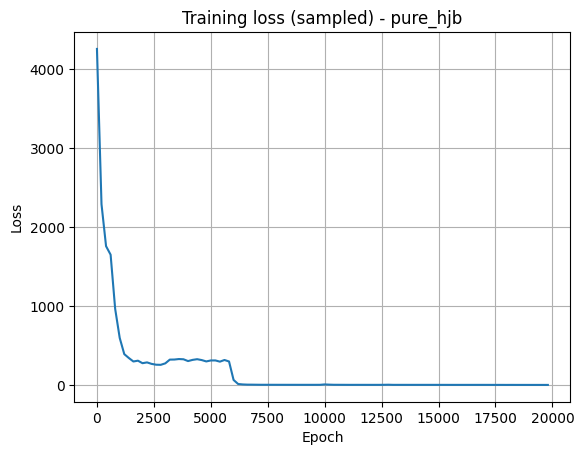

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


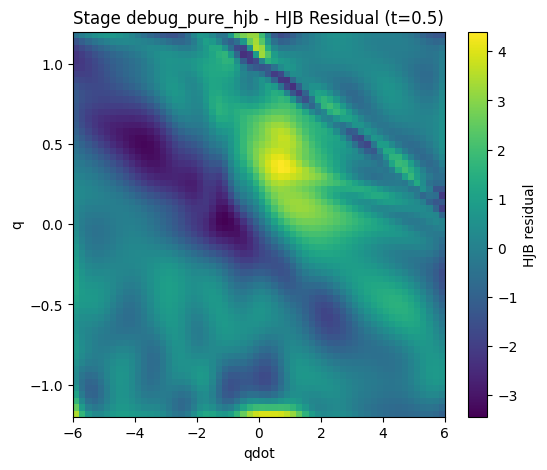

[rollout] max|q|=0.389 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1338 max_err=0.2900 peak_q=0.3891 peak_q_ref=0.5000 time_to_peak=0.7140 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=11.6246 rollout_peak_u_bounded=11.6246


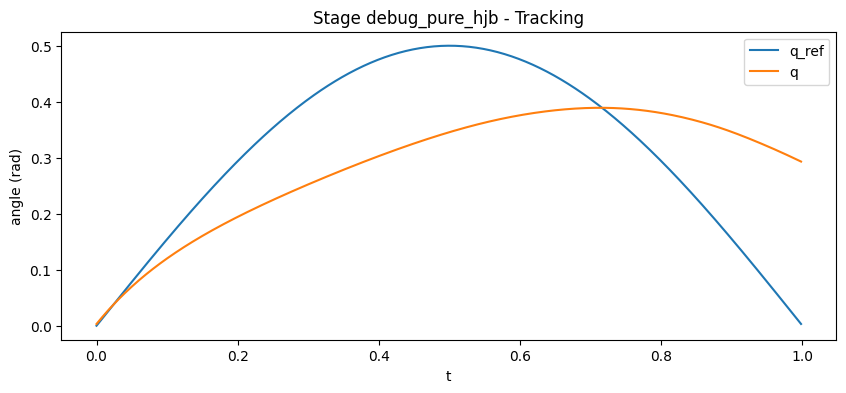

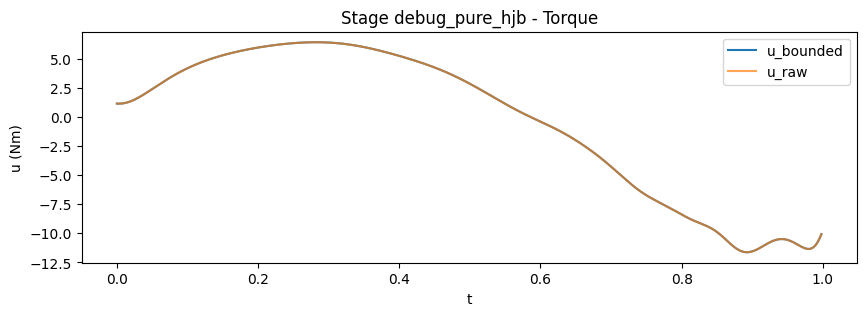

[compare] RMSE learned=0.1338 PD=0.1346 torque_corr=0.9961 torque_mae=0.3429 gain_ratio=0.9849
[compare] high_err_mean_u_learned=-0.3662 high_err_mean_u_pd=-0.5192


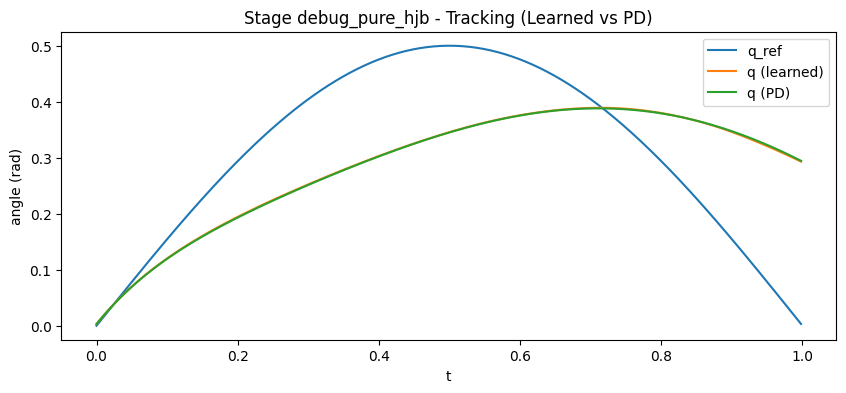

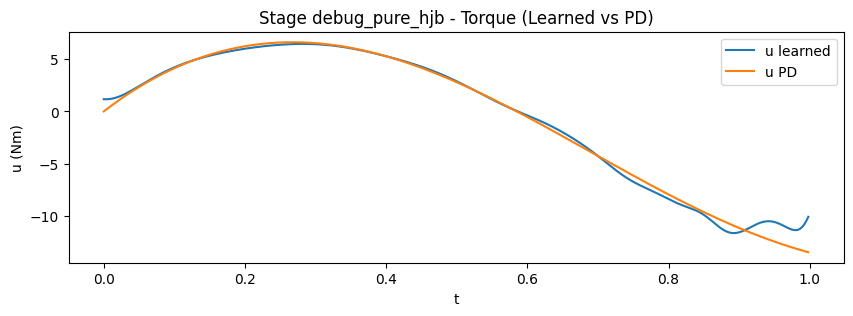

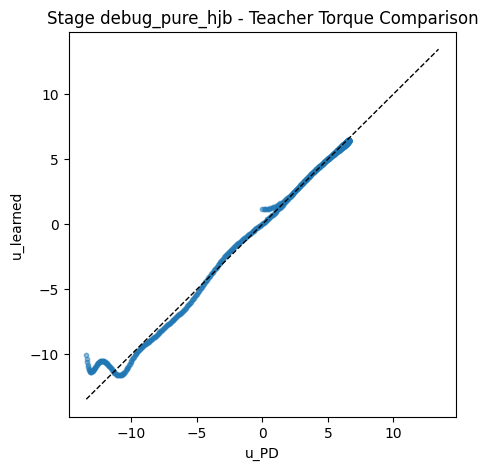

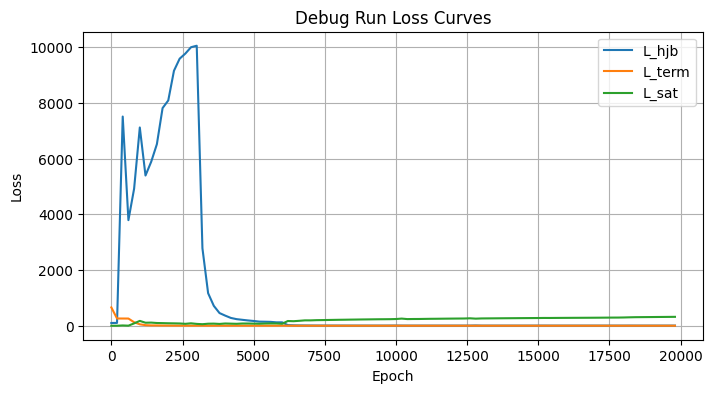

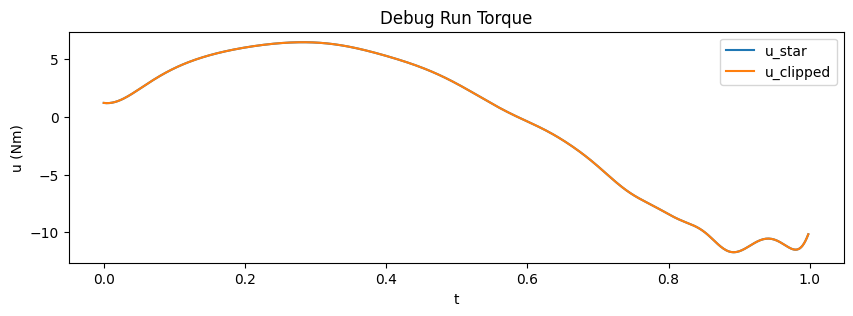

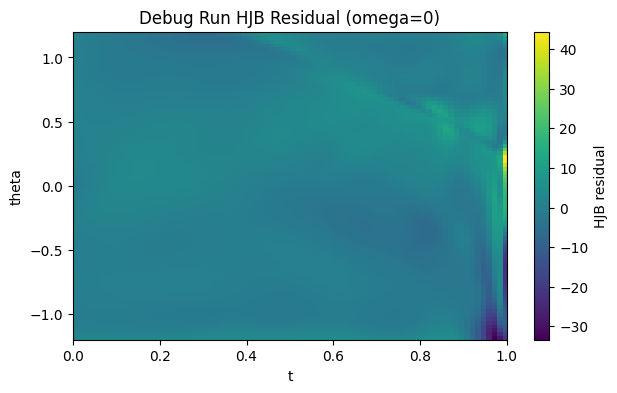

In [21]:
# Debug Stabilization Run (config overrides)
debug_cfg_override = {
    "dynamics": {
        "use_residual": False,
        "residual_guard": True,
        "guard_theta_min": -1.0,
        "guard_theta_max": 1.0,
        "guard_omega_min": -5.0,
        "guard_omega_max": 5.0,
    },
    "control": {
        "u_max": 20.0,
        "use_saturated_hjb": True,
    },
    "reference": {
        "type": "synthetic",
        "synthetic": {
            "kind": "half_sine",
            "amplitude": 0.5,
            "offset": 0.0,
            "period": 1.0,
        },
    },
    "collocation": {
        "theta_min": -1.2,
        "theta_max": 1.2,
        "omega_min": -6.0,
        "omega_max": 6.0,
        "t_min": 0.0,
        "t_max": 1.0,
    },
    "cost_weights": {
        "w_u": 0.02,
    },
}

debug_train_overrides = {
    "lambda_hjb": 1.0,
    "lambda_term": 1.0,
    "lambda_data": 0.0,
    "lambda_traj": 0.0,
    "lambda_sat": 0.0,
}

net_dbg, cfg_dbg, residual_dbg, ckpt_dbg, hist_dbg = train_stage(
    "pure_hjb",
    overrides=debug_train_overrides,
    init_ckpt=None,
    cfg_override=debug_cfg_override,
)

evaluate_stage(net_dbg, cfg_dbg, residual_dbg, "debug_pure_hjb")

# Training curves
plt.figure(figsize=(8, 4))
plt.plot(hist_dbg["epoch"], hist_dbg["L_hjb"], label="L_hjb")
plt.plot(hist_dbg["epoch"], hist_dbg["L_term"], label="L_term")
plt.plot(hist_dbg["epoch"], hist_dbg["L_sat"], label="L_sat")
plt.title("Debug Run Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Torque plot with u_star and u_clipped
cfg_hjb_dbg = HJBConfig(
    w_track=float(cfg_dbg["cost_weights"]["w_track"]),
    w_omega=float(cfg_dbg["cost_weights"]["w_omega"]),
    w_u=float(cfg_dbg["cost_weights"]["w_u"]),
)
control_dbg = cfg_dbg.get("control", {})
u_max_dbg = float(control_dbg.get("u_max", 20.0))
use_saturated_dbg = bool(control_dbg.get("use_saturated_hjb", True))
use_tanh_dbg = bool(control_dbg.get("use_tanh_saturation", False))
sat_method_dbg = "tanh" if use_tanh_dbg else "clamp"
u_scale_dbg = float(control_dbg.get("u_scale", 1.0))
cap_multiplier_dbg = bool(control_dbg.get("cap_multiplier", True))
multiplier_cap_dbg = float(control_dbg.get("multiplier_cap", 1e3))

theta_ref_dbg, theta_ref_dot_dbg = build_reference(cfg_dbg)

def simulate_with_u_star(net, T=1.0, dt=0.002):
    steps = int(T / dt)
    t = np.linspace(0.0, T, steps + 1, dtype=np.float32)
    q0 = theta_ref_dbg(torch.tensor([[0.0]], device=device)).detach()
    qd0 = theta_ref_dot_dbg(torch.tensor([[0.0]], device=device)).detach()
    x = torch.cat([q0, qd0], dim=1).to(device).requires_grad_(True)

    us_star = []
    us_clip = []
    for k in range(steps):
        q = x[:, 0:1]
        qd = x[:, 1:2]
        tt = torch.tensor([[t[k]]], device=device, dtype=torch.float32, requires_grad=True)
        _, _, _, V_qd = V_eval_with_grads(net, q, qd, tt)
        u_star, u_clip = compute_control(
            V_qd,
            exo_params,
            cfg_hjb_dbg.w_u,
            u_max=u_max_dbg,
            saturation_method=sat_method_dbg,
            u_scale=u_scale_dbg,
            cap_multiplier=cap_multiplier_dbg,
            multiplier_cap=multiplier_cap_dbg,
        )
        u_used = u_clip if use_saturated_dbg else u_star
        dx = knee_dynamics_torch(x, u_used, exo_params, residual_net=None)
        x = (x + dt * dx).detach().requires_grad_(True)
        us_star.append(float(u_star.detach().cpu().numpy().squeeze()))
        us_clip.append(float(u_clip.detach().cpu().numpy().squeeze()))

    return t[:-1], np.array(us_star), np.array(us_clip)

t_torque, u_star_hist, u_clip_hist = simulate_with_u_star(net_dbg, T=T)
plt.figure(figsize=(10, 3))
plt.plot(t_torque, u_star_hist, label="u_star")
plt.plot(t_torque, u_clip_hist, label="u_clipped")
plt.title("Debug Run Torque")
plt.xlabel("t")
plt.ylabel("u (Nm)")
plt.legend()
plt.grid(False)
plt.show()

# HJB residual heatmap over (theta,t) with omega=0
n_theta = 80
n_t = 80
th = torch.linspace(cfg_dbg["collocation"]["theta_min"], cfg_dbg["collocation"]["theta_max"], n_theta, device=device)
tr = torch.linspace(cfg_dbg["collocation"]["t_min"], cfg_dbg["collocation"]["t_max"], n_t, device=device)
TH, TT = torch.meshgrid(th, tr, indexing="ij")
TH = TH.reshape(-1, 1).requires_grad_(True)
TT = TT.reshape(-1, 1).requires_grad_(True)
OM = torch.zeros_like(TH).requires_grad_(True)

V, V_t, V_th, V_om = V_eval_with_grads(net_dbg, TH, OM, TT)
ref_th = theta_ref_dbg(TT)
ref_om = theta_ref_dot_dbg(TT)
res = hjb_residual(
    TH,
    OM,
    TT,
    V,
    V_t,
    V_th,
    V_om,
    exo_params,
    cfg_hjb_dbg,
    ref_th,
    ref_om,
    u_max=u_max_dbg,
    use_saturated_hjb=use_saturated_dbg,
    saturation_method=sat_method_dbg,
    u_scale=u_scale_dbg,
    cap_multiplier=cap_multiplier_dbg,
    multiplier_cap=multiplier_cap_dbg,
)
res_grid = res.detach().cpu().numpy().reshape(n_theta, n_t)

plt.figure(figsize=(7, 4))
plt.imshow(
    res_grid,
    extent=[cfg_dbg["collocation"]["t_min"], cfg_dbg["collocation"]["t_max"], cfg_dbg["collocation"]["theta_min"], cfg_dbg["collocation"]["theta_max"]],
    origin="lower",
    aspect="auto",
)
plt.colorbar(label="HJB residual")
plt.xlabel("t")
plt.ylabel("theta")
plt.title("Debug Run HJB Residual (omega=0)")
plt.show()


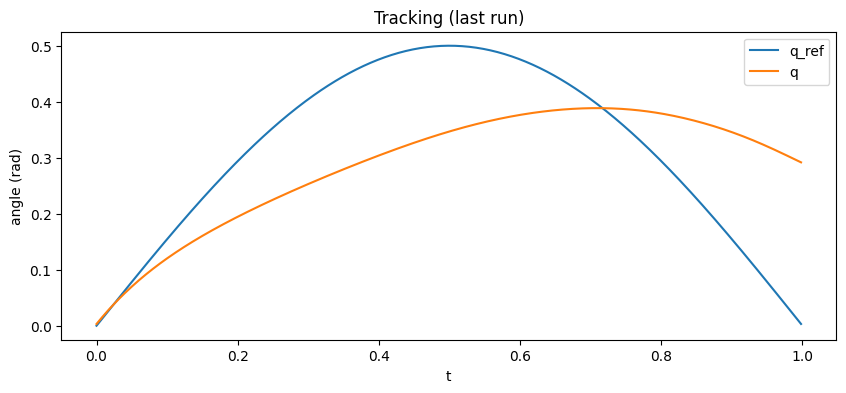

In [22]:
# Extra simulation with the last trained net (optional)
if "net" in globals():
    last_cfg = stage_cfg if "stage_cfg" in globals() else cfg
    last_weights = last_cfg["cost_weights"]
    last_control = last_cfg.get("control", {})
    last_train = last_cfg["training"]
    last_u_max = float(last_control.get("u_max", last_train.get("u_max", 20.0)))

    cfg_hjb_last = HJBConfig(
        w_track=float(last_weights["w_track"]),
        w_omega=float(last_weights["w_omega"]),
        w_u=float(last_weights["w_u"]),
    )
    theta_ref_last, theta_ref_dot_last = build_reference(last_cfg)
    t_sim, xs, us, u_raws, q_ref, oob_hit = simulate_policy(
    net,
    last_cfg,
    cfg_hjb_last,
    theta_ref_last,
    theta_ref_dot_last,
    last_u_max,
    residual_net,
    T=T,
    )
    plt.figure(figsize=(10, 4))
    plt.plot(t_sim, q_ref, label="q_ref")
    plt.plot(t_sim, xs[:, 0], label="q")
    plt.title("Tracking (last run)")
    plt.xlabel("t")
    plt.ylabel("angle (rad)")
    plt.legend()
    plt.grid(False)
    plt.show()


In [23]:
print(theta_ref(torch.tensor([[0.5]], dtype=torch.float32)).item())


0.5


## Closed-loop Simulation with Learned Policy


[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.1438 omega=1.3119 control=0.0000
[data debug] q min/max -0.07538820058107376 1.2925297021865845
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -9.535204887390137 7.365649700164795
[data debug] u min/max -45.87004470825195 44.240577697753906
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-6.000,5.999] u_raw[-0.035,0.015] u_bounded[-0.035,0.015] ctrl_sig[-0.008,0.018] sat_ratio 0.000 grad_ema 391.955 L_hjb 100.8343 L_term 593.7642 L_data 179.5642 L_rollout 0.0054 L_u_match 147.7237 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<12:55:31,  2.33s/it]

[rollout-check] epoch 0 RMSE=0.1775


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-6.000,5.999] u_raw[-163.005,87.272] u_bounded[-20.000,20.000] ctrl_sig[-45.966,85.855] sat_ratio 0.463 grad_ema 536.559 L_hjb 4.3396 L_term 0.1864 L_data 211.8119 L_rollout 0.0031 L_u_match 8.5186 L_sat 280.2840


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:49:52<01:02,  3.16it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-6.000,5.999] u_raw[-168.378,84.562] u_bounded[-20.000,20.000] ctrl_sig[-44.539,88.685] sat_ratio 0.461 grad_ema 387.723 L_hjb 4.6125 L_term 0.1865 L_data 224.9530 L_rollout 0.0022 L_u_match 8.5885 L_sat 286.0153


Training pure_hjb: 100%|██████████| 20000/20000 [1:50:56<00:00,  3.00it/s]

[train_bounds] train_observed_u_raw_range [-223.608, 100.876]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-53.131, 117.774]


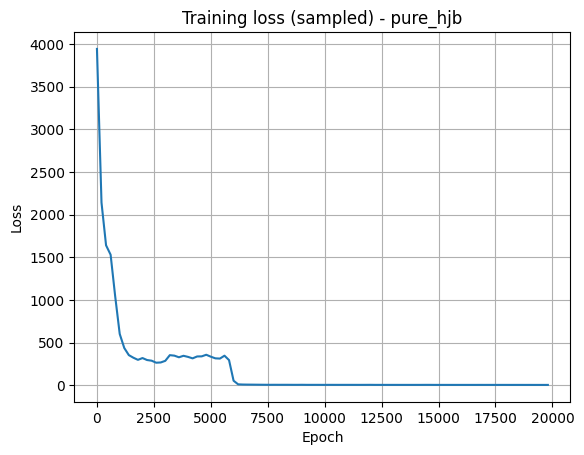

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


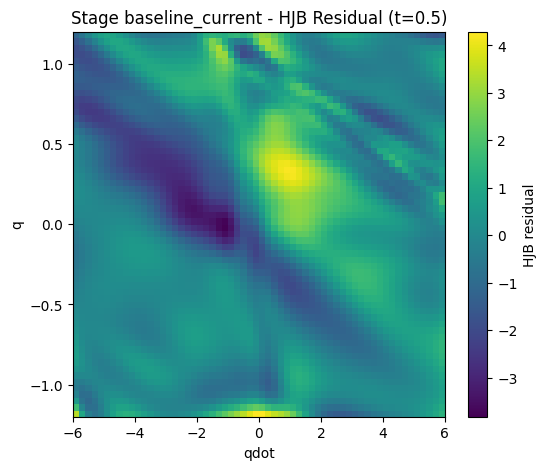

[rollout] max|q|=0.387 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1337 max_err=0.2892 peak_q=0.3873 peak_q_ref=0.5000 time_to_peak=0.7120 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=17.6466 rollout_peak_u_bounded=17.6466


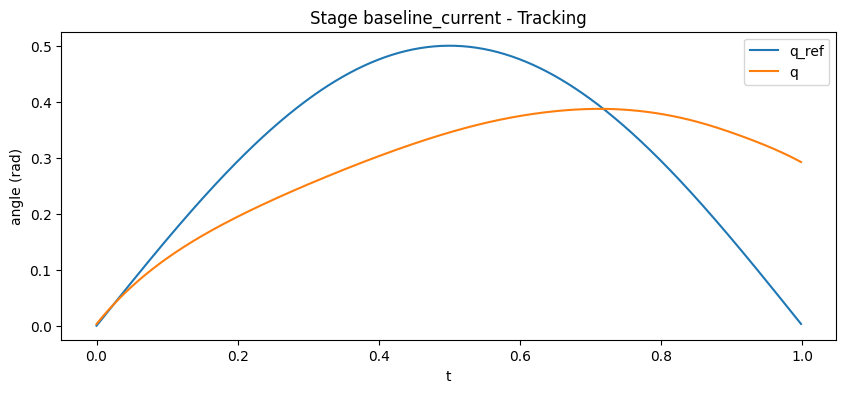

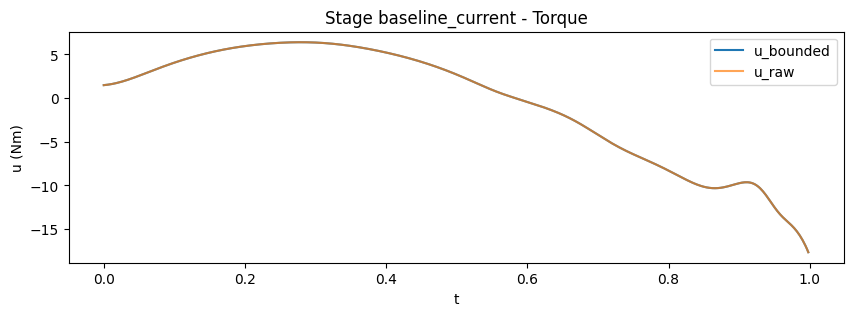

[compare] RMSE learned=0.1337 PD=0.1346 torque_corr=0.9950 torque_mae=0.3805 gain_ratio=0.9983
[compare] high_err_mean_u_learned=-0.6281 high_err_mean_u_pd=-0.4922


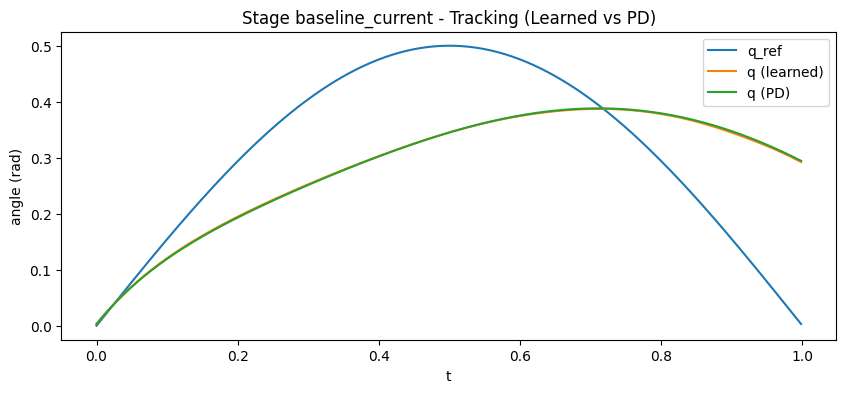

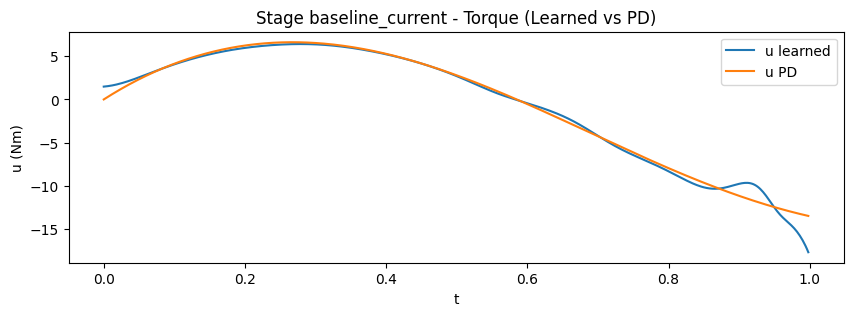

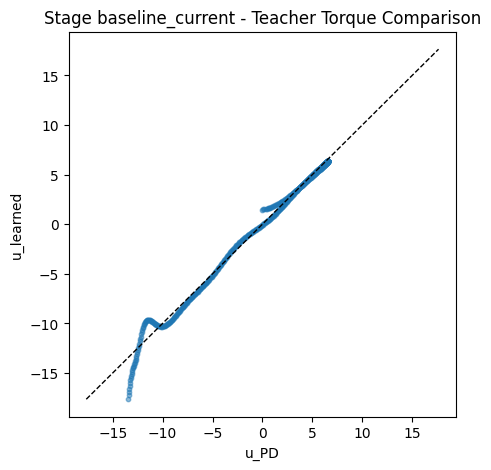

{'name': 'baseline_current', 'rmse_learned': 0.13369722664356232, 'rmse_pd': 0.13455602526664734, 'rollout_peak_u_raw': 17.646617889404297, 'rollout_peak_u_bounded': 17.646617889404297, 'max_q_error': 0.28919029235839844, 'torque_corr': 0.9949773439344557, 'torque_mae_pd': 0.38051247369870544, 'torque_gain_ratio': 0.9983292426323818}
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0492 omega=1.3171 control=0.0000
[data debug] q min/max -0.08805766701698303 1.2753350734710693
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -7.998866081237793 9.460131645202637
[data debug] u min/max -45.87004470825195 45.181175231933594
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.199,1.200] qd[-6.000,5.998] u_raw[-0.016,0.083] u_bounded[-0.016,0.083] ctrl_sig[-0.044,0.008] sat_ratio 0.000 grad_ema 432.211 L_hjb 98.1282 L_term 652.7966 L_data 178.4885 L_rollout 0.0047 L_u_match 146.7159 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<13:57:01,  2.51s/it]

[rollout-check] epoch 0 RMSE=0.1771


...

epoch 19600 | phase=stage_C q[-1.199,1.200] qd[-6.000,5.998] u_raw[-176.706,90.050] u_bounded[-20.000,20.000] ctrl_sig[-47.430,93.071] sat_ratio 0.470 grad_ema 626.955 L_hjb 4.1276 L_term 0.1667 L_data 225.6289 L_rollout 0.0032 L_u_match 7.2521 L_sat 314.8264


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:50:28<01:04,  3.09it/s]

epoch 19800 | phase=stage_C q[-1.199,1.200] qd[-6.000,5.998] u_raw[-181.005,89.857] u_bounded[-20.000,20.000] ctrl_sig[-47.328,95.335] sat_ratio 0.470 grad_ema 627.033 L_hjb 4.0799 L_term 0.1572 L_data 211.2780 L_rollout 0.0022 L_u_match 7.2145 L_sat 316.6615


Training pure_hjb: 100%|██████████| 20000/20000 [1:51:33<00:00,  2.99it/s]

[train_bounds] train_observed_u_raw_range [-232.981, 93.035]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-49.002, 122.711]


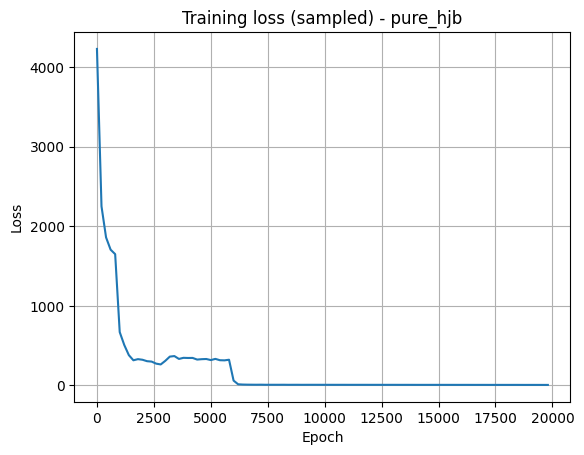

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


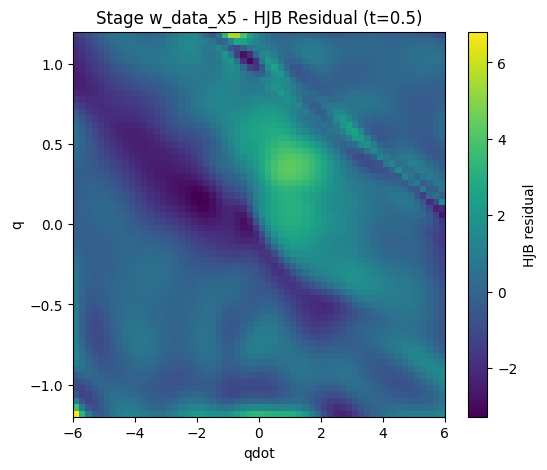

[rollout] max|q|=0.396 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1346 max_err=0.2970 peak_q=0.3956 peak_q_ref=0.5000 time_to_peak=0.7120 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=12.6572 rollout_peak_u_bounded=12.6572


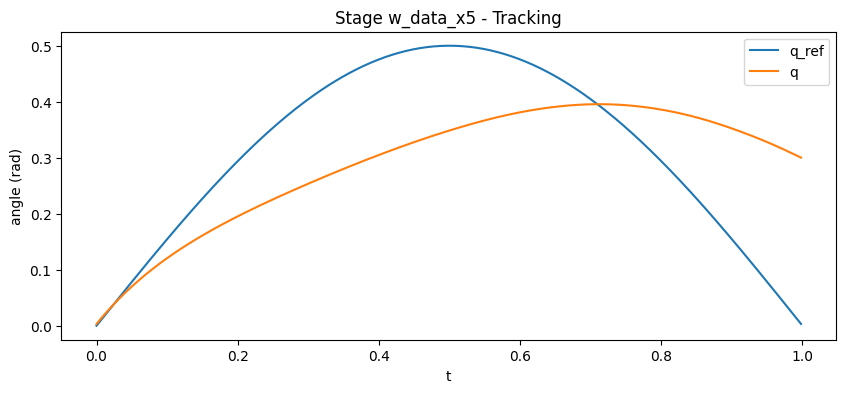

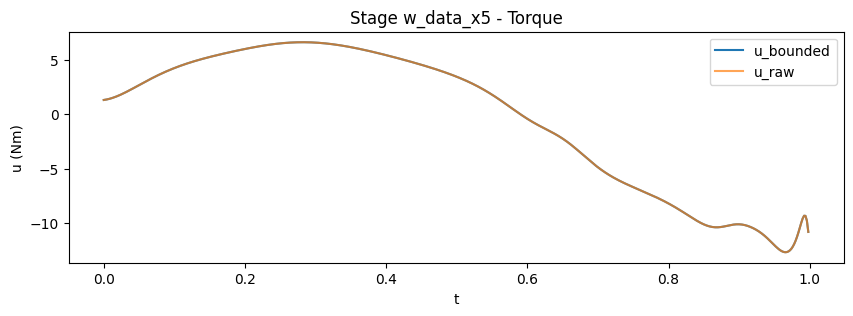

[compare] RMSE learned=0.1346 PD=0.1346 torque_corr=0.9957 torque_mae=0.4059 gain_ratio=1.0124
[compare] high_err_mean_u_learned=-0.2669 high_err_mean_u_pd=-0.6238


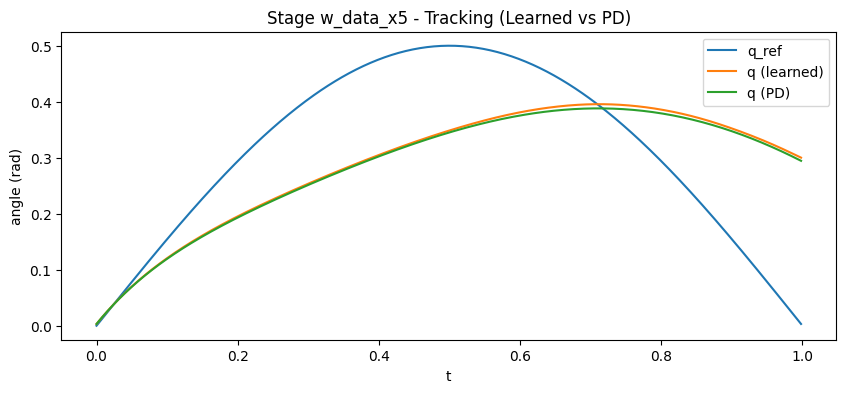

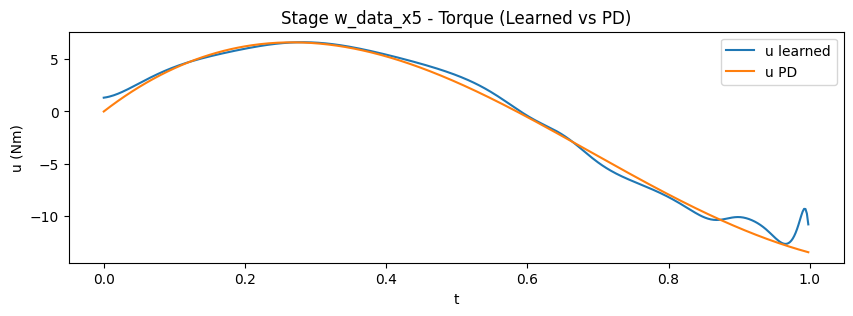

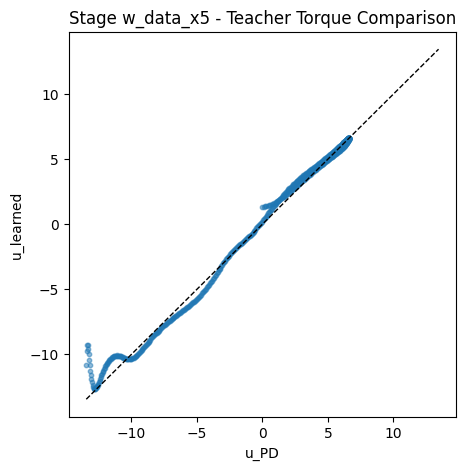

{'name': 'w_data_x5', 'rmse_learned': 0.13463737070560455, 'rmse_pd': 0.13455602526664734, 'rollout_peak_u_raw': 12.657190322875977, 'rollout_peak_u_bounded': 12.657190322875977, 'max_q_error': 0.2969963252544403, 'torque_corr': 0.9957462389270663, 'torque_mae_pd': 0.4059465506523848, 'torque_gain_ratio': 1.0123819066501776}
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.1078 omega=1.3129 control=0.0000
[data debug] q min/max -0.07892876118421555 1.272160530090332
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -7.539919853210449 9.497928619384766
[data debug] u min/max -45.21256637573242 47.7271842956543
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-5.999,5.999] u_raw[0.008,0.045] u_bounded[0.008,0.045] ctrl_sig[-0.024,-0.004] sat_ratio 0.000 grad_ema 384.121 L_hjb 100.5322 L_term 624.9387 L_data 178.0669 L_rollout 0.0036 L_u_match 143.7813 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<12:32:34,  2.26s/it]

[rollout-check] epoch 0 RMSE=0.1769


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-5.999,5.999] u_raw[-172.834,108.826] u_bounded[-20.000,20.000] ctrl_sig[-57.319,91.032] sat_ratio 0.469 grad_ema 679.519 L_hjb 4.5233 L_term 0.1745 L_data 222.8943 L_rollout 0.0038 L_u_match 8.6588 L_sat 289.4658


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:49:32<01:05,  3.05it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-5.999,5.999] u_raw[-179.696,112.429] u_bounded[-20.000,20.000] ctrl_sig[-59.216,94.646] sat_ratio 0.472 grad_ema 711.123 L_hjb 4.6988 L_term 0.3015 L_data 227.3997 L_rollout 0.0032 L_u_match 8.9557 L_sat 301.9147


Training pure_hjb: 100%|██████████| 20000/20000 [1:50:35<00:00,  3.01it/s]

[train_bounds] train_observed_u_raw_range [-385.952, 115.033]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-60.588, 203.281]


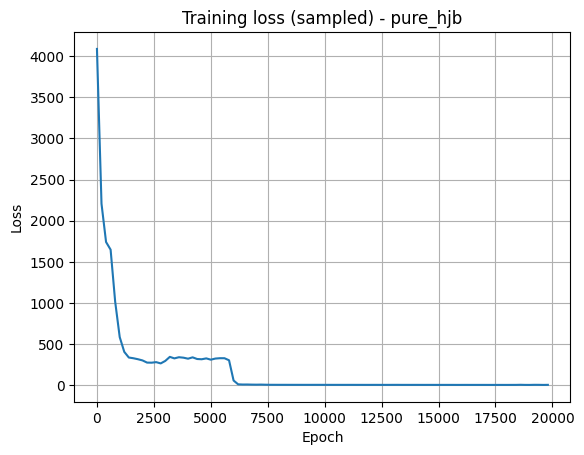

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


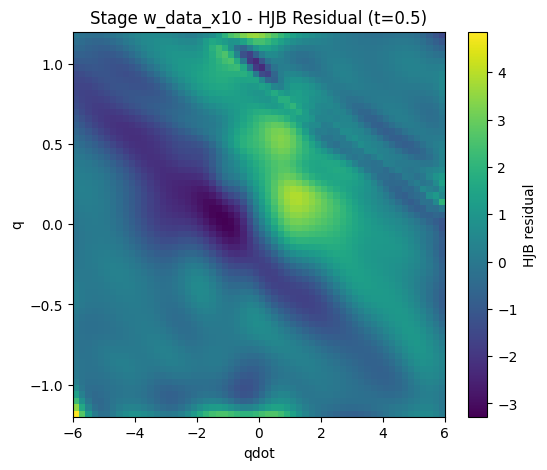

[rollout] max|q|=0.394 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1349 max_err=0.2951 peak_q=0.3936 peak_q_ref=0.5000 time_to_peak=0.7120 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=11.5448 rollout_peak_u_bounded=11.5448


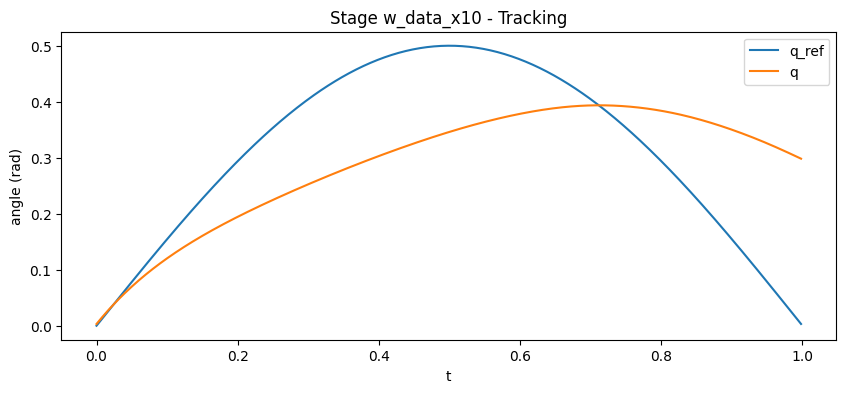

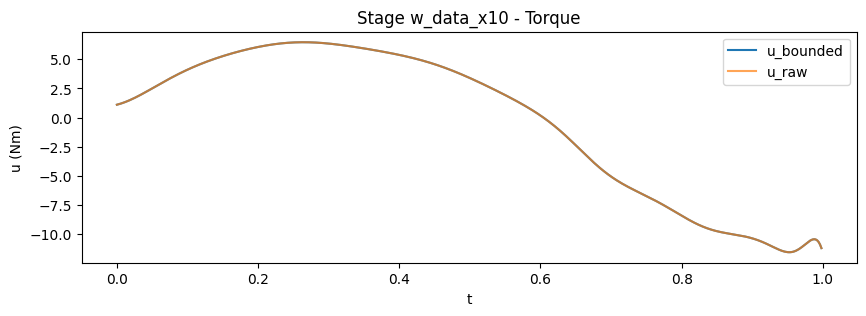

[compare] RMSE learned=0.1349 PD=0.1346 torque_corr=0.9955 torque_mae=0.4649 gain_ratio=1.0035
[compare] high_err_mean_u_learned=-0.1900 high_err_mean_u_pd=-0.5726


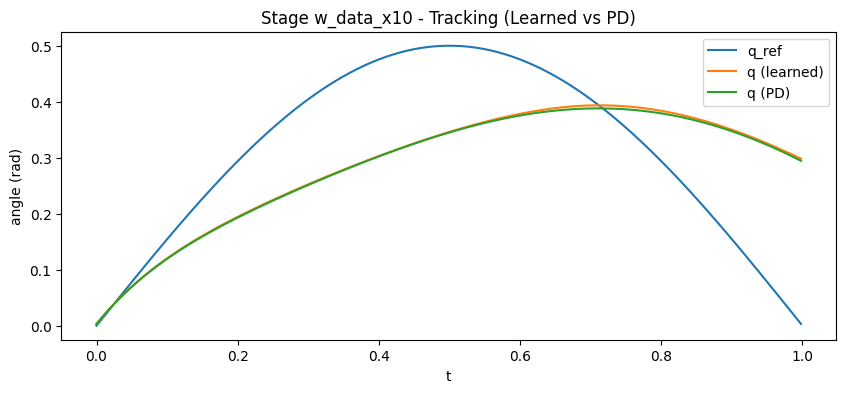

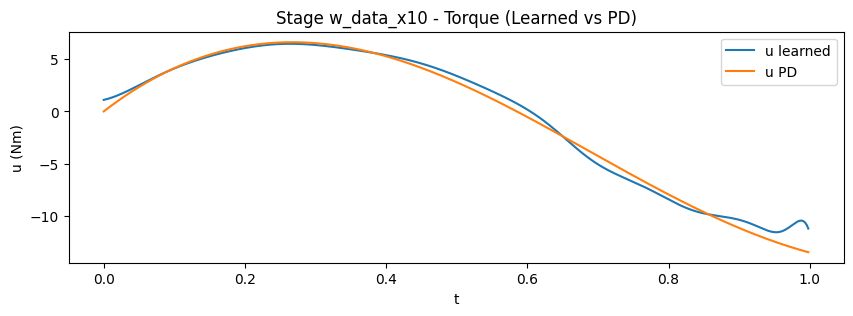

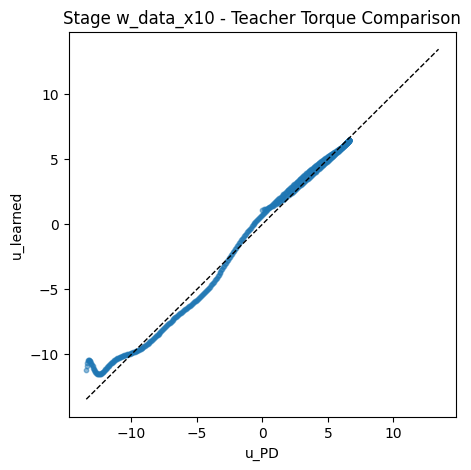

{'name': 'w_data_x10', 'rmse_learned': 0.13485503196716309, 'rmse_pd': 0.13455602526664734, 'rollout_peak_u_raw': 11.544757843017578, 'rollout_peak_u_bounded': 11.544757843017578, 'max_q_error': 0.29514989256858826, 'torque_corr': 0.9955261045511549, 'torque_mae_pd': 0.4649060423979536, 'torque_gain_ratio': 1.0035141418254183}
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0873 omega=1.3200 control=0.0002
[data debug] q min/max -0.11081010848283768 1.2820221185684204
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -10.63182258605957 9.460131645202637
[data debug] u min/max -48.31050109863281 44.987403869628906
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-5.997,6.000] u_raw[-0.109,-0.065] u_bounded[-0.109,-0.065] ctrl_sig[0.034,0.057] sat_ratio 0.000 grad_ema 421.747 L_hjb 99.3079 L_term 651.1143 L_data 178.7477 L_rollout 0.0028 L_u_match 140.9952 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<12:23:16,  2.23s/it]

[rollout-check] epoch 0 RMSE=0.1786


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-5.997,6.000] u_raw[-279.292,114.581] u_bounded[-20.000,20.000] ctrl_sig[-60.350,147.103] sat_ratio 0.472 grad_ema 444.439 L_hjb 17.3855 L_term 0.1101 L_data 207.4333 L_rollout 0.0031 L_u_match 4.9348 L_sat 339.0639


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:50:22<01:04,  3.11it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-5.997,6.000] u_raw[-287.188,115.777] u_bounded[-20.000,20.000] ctrl_sig[-60.980,151.262] sat_ratio 0.470 grad_ema 443.659 L_hjb 17.2139 L_term 0.1405 L_data 220.0474 L_rollout 0.0036 L_u_match 4.9120 L_sat 341.5916


Training pure_hjb: 100%|██████████| 20000/20000 [1:51:26<00:00,  2.99it/s]

[train_bounds] train_observed_u_raw_range [-303.605, 126.878]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-66.827, 159.909]


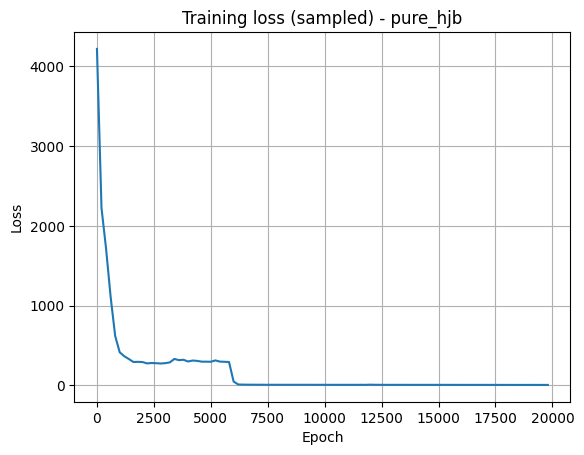

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


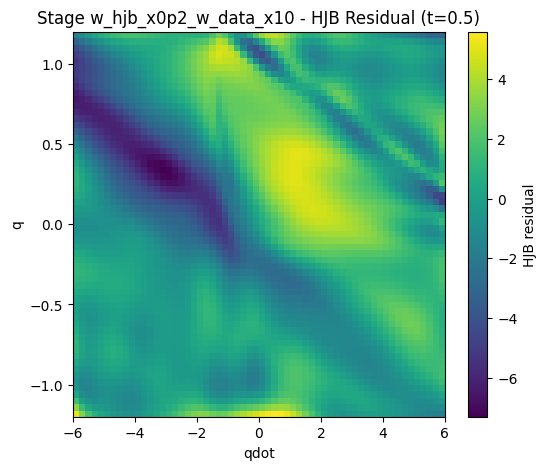

[rollout] max|q|=0.389 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1337 max_err=0.2907 peak_q=0.3890 peak_q_ref=0.5000 time_to_peak=0.7060 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=12.9120 rollout_peak_u_bounded=12.9120


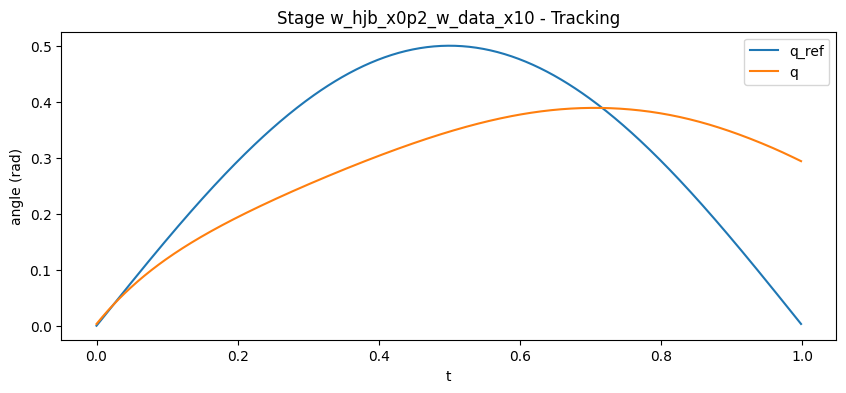

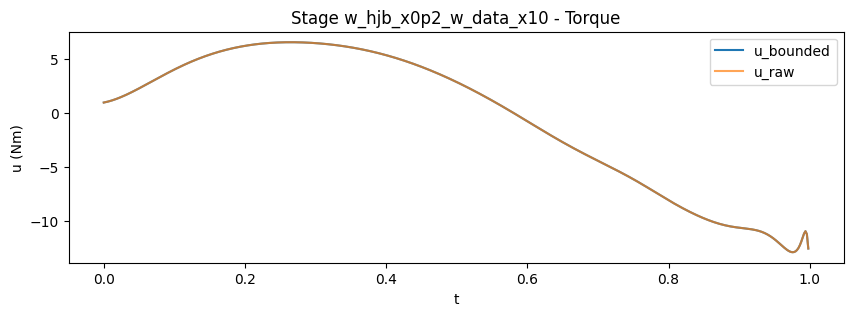

[compare] RMSE learned=0.1337 PD=0.1346 torque_corr=0.9988 torque_mae=0.1809 gain_ratio=0.9975
[compare] high_err_mean_u_learned=-0.3544 high_err_mean_u_pd=-0.4963


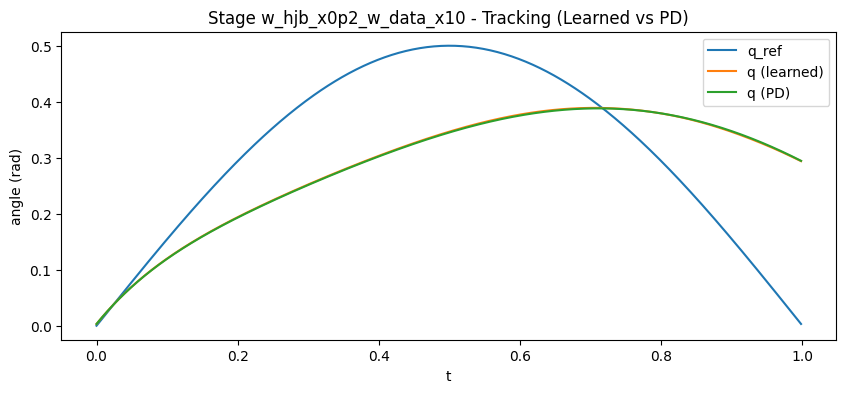

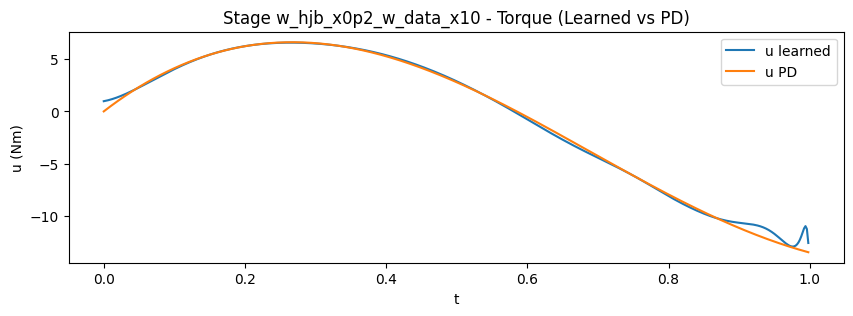

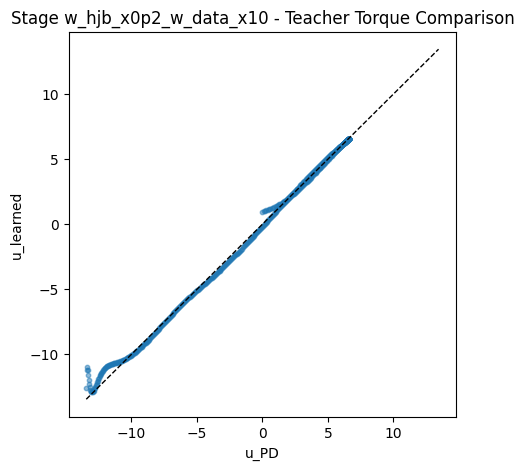

{'name': 'w_hjb_x0p2_w_data_x10', 'rmse_learned': 0.13367876410484314, 'rmse_pd': 0.13455602526664734, 'rollout_peak_u_raw': 12.912009239196777, 'rollout_peak_u_bounded': 12.912009239196777, 'max_q_error': 0.2907227575778961, 'torque_corr': 0.9988450810686775, 'torque_mae_pd': 0.18090190809965134, 'torque_gain_ratio': 0.997520189236211}
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0834 omega=1.3203 control=0.0001
[data debug] q min/max -0.07919114828109741 1.2820221185684204
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -11.382651329040527 13.220964431762695
[data debug] u min/max -44.005985260009766 38.366336822509766
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-5.999,6.000] u_raw[-0.065,-0.024] u_bounded[-0.065,-0.024] ctrl_sig[0.013,0.034] sat_ratio 0.000 grad_ema 420.730 L_hjb 99.5721 L_term 615.5411 L_data 178.2263 L_rollout 0.0061 L_u_match 149.6004 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<12:37:56,  2.27s/it]

[rollout-check] epoch 0 RMSE=0.1784


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-5.999,6.000] u_raw[-162.442,86.908] u_bounded[-20.000,20.000] ctrl_sig[-45.774,85.558] sat_ratio 0.462 grad_ema 846.183 L_hjb 4.2667 L_term 0.5637 L_data 214.3705 L_rollout 0.0033 L_u_match 8.0503 L_sat 302.5625


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:50:06<01:04,  3.09it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-5.999,6.000] u_raw[-173.436,90.077] u_bounded[-20.000,20.000] ctrl_sig[-47.443,91.349] sat_ratio 0.467 grad_ema 836.152 L_hjb 4.2743 L_term 0.2030 L_data 221.8698 L_rollout 0.0024 L_u_match 8.2790 L_sat 323.2158


Training pure_hjb: 100%|██████████| 20000/20000 [1:51:11<00:00,  3.00it/s]

[train_bounds] train_observed_u_raw_range [-286.890, 104.938]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-55.271, 151.105]


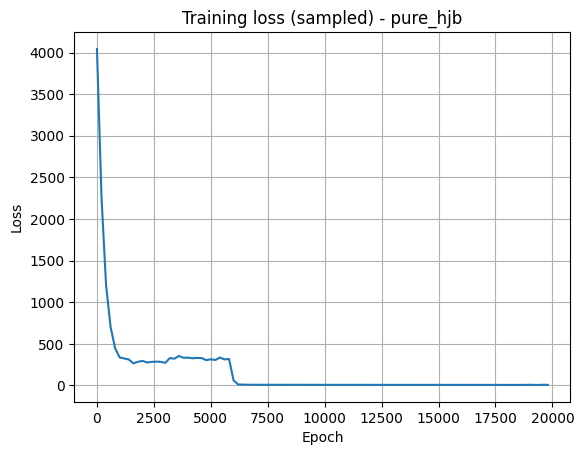

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt


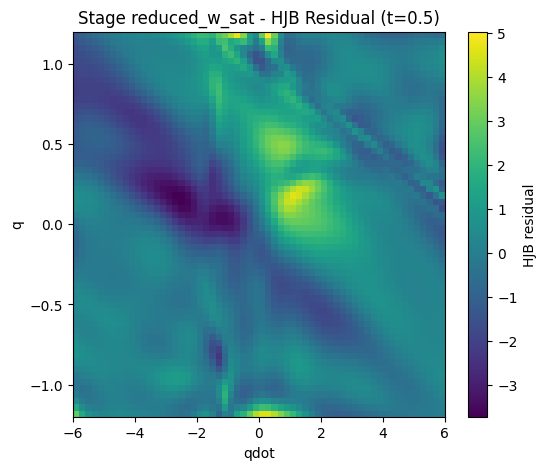

[rollout] max|q|=0.392 max|dq|=1.551 nan=False oob=None
[tracking] rmse=0.1354 max_err=0.3014 peak_q=0.3924 peak_q_ref=0.5000 time_to_peak=0.7220 time_to_peak_ref=0.5000
[rollout] rollout_peak_u_raw=14.3196 rollout_peak_u_bounded=14.3196


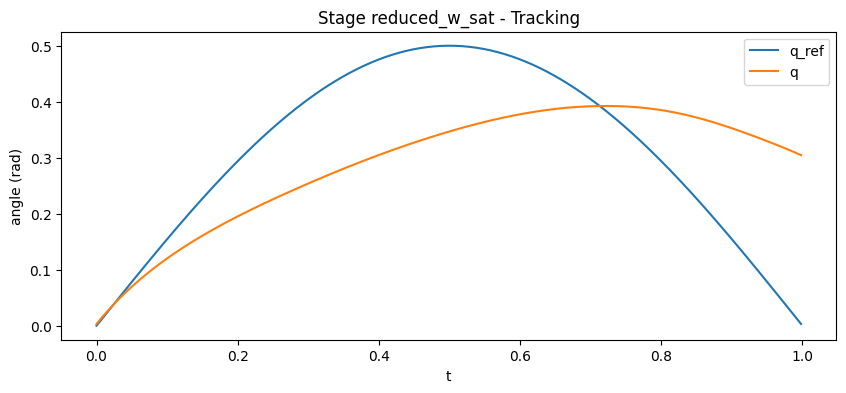

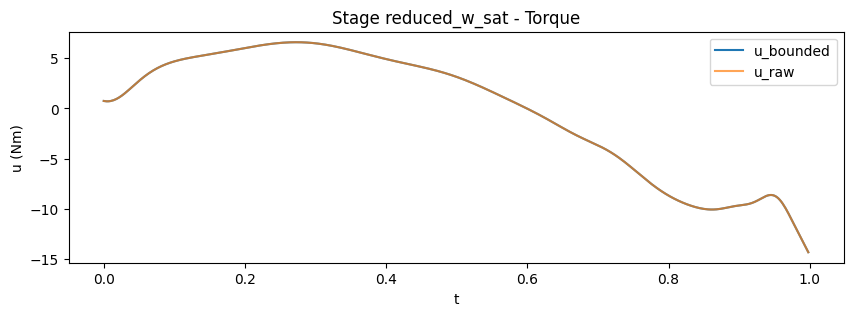

[compare] RMSE learned=0.1354 PD=0.1346 torque_corr=0.9929 torque_mae=0.5413 gain_ratio=0.9621
[compare] high_err_mean_u_learned=-0.2117 high_err_mean_u_pd=-0.5960


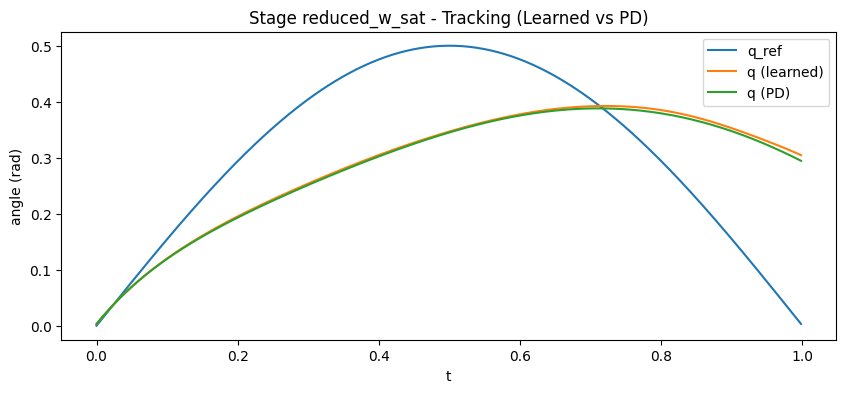

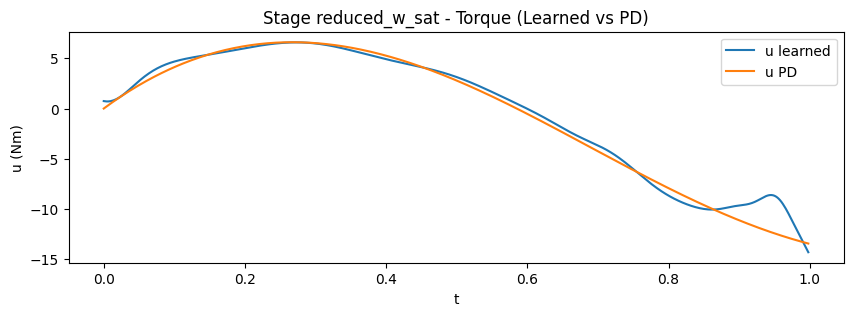

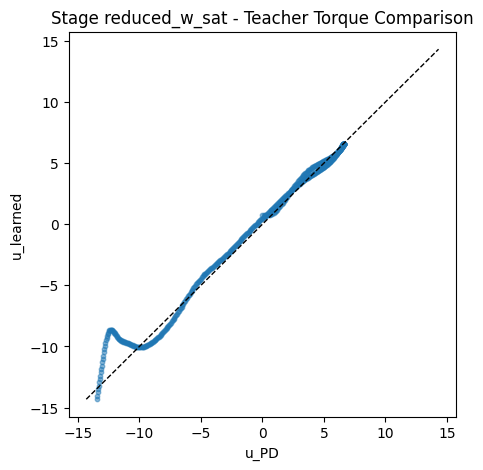

{'name': 'reduced_w_sat', 'rmse_learned': 0.13543640077114105, 'rmse_pd': 0.13455602526664734, 'rollout_peak_u_raw': 14.3196382522583, 'rollout_peak_u_bounded': 14.3196382522583, 'max_q_error': 0.30143463611602783, 'torque_corr': 0.992860587637474, 'torque_mae_pd': 0.5412721835970878, 'torque_gain_ratio': 0.962089607053882}


In [24]:
# Loss-weight sweep helper
RUN_WEIGHT_SWEEPS = True  #False
SWEEP_STAGE = train.get("mode", "pure_hjb")
SWEEP_TRAIN_OVERRIDES = None
SWEEP_CFG_OVERRIDE = None
SWEEP_PLOTS = True  #False

WEIGHT_SWEEPS = [
    {"name": "baseline_current", "loss": {}},
    {"name": "w_data_x5", "loss": {"w_data": 5.0 * float(cfg.get("loss", {}).get("w_data", 1.0))}},
    {"name": "w_data_x10", "loss": {"w_data": 10.0 * float(cfg.get("loss", {}).get("w_data", 1.0))}},
    {
        "name": "w_hjb_x0p2_w_data_x10",
        "loss": {
            "w_hjb": 0.2 * float(cfg.get("loss", {}).get("w_hjb", 1.0)),
            "w_data": 10.0 * float(cfg.get("loss", {}).get("w_data", 1.0)),
        },
    },
    {"name": "reduced_w_sat", "loss": {"w_sat": 0.2 * float(cfg.get("loss", {}).get("w_sat", 1.0))}},
]


def run_weight_sweeps(sweep_specs, stage_name=None, train_overrides=None, cfg_override=None, make_plots=False):
    stage_name = stage_name or train.get("mode", "pure_hjb")
    rows = []
    for spec in sweep_specs:
        sweep_cfg_override = copy.deepcopy(cfg_override) if cfg_override else {}
        deep_update(sweep_cfg_override, {"loss": spec.get("loss", {})})
        net_sw, cfg_sw, residual_sw, ckpt_sw, hist_sw = train_stage(
            stage_name,
            overrides=train_overrides,
            init_ckpt=None,
            cfg_override=sweep_cfg_override,
        )
        metrics = evaluate_stage(net_sw, cfg_sw, residual_sw, spec["name"], make_plots=make_plots)
        row = {
            "name": spec["name"],
            "rmse_learned": metrics.get("rmse_learned"),
            "rmse_pd": metrics.get("rmse_pd"),
            "rollout_peak_u_raw": metrics.get("rollout_peak_u_raw"),
            "rollout_peak_u_bounded": metrics.get("rollout_peak_u_bounded"),
            "max_q_error": metrics.get("max_q_error"),
            "torque_corr": metrics.get("torque_corr"),
            "torque_mae_pd": metrics.get("torque_mae_pd"),
            "torque_gain_ratio": metrics.get("torque_gain_ratio"),
        }
        rows.append(row)
        print(row)
    return rows


if RUN_WEIGHT_SWEEPS:
    sweep_results = run_weight_sweeps(
        WEIGHT_SWEEPS,
        stage_name=SWEEP_STAGE,
        train_overrides=SWEEP_TRAIN_OVERRIDES,
        cfg_override=SWEEP_CFG_OVERRIDE,
        make_plots=SWEEP_PLOTS,
    )
else:
    print("Set RUN_WEIGHT_SWEEPS = True to train/report the weight sweep experiments.")


## Publication-Quality Results and Figures
This section generates standalone figures, exports summary metrics, and optionally runs ablation retraining for publication-ready comparison plots.


In [31]:
from pathlib import Path
import csv

RESULTS_DIR = ROOT / "results" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
set_global_seed(int(cfg.get("seed", 42)))

RUN_PUBLICATION_RESULTS = True
RUN_ABLATIONS = True
PUBLICATION_STAGE = train.get("mode", "pure_hjb")
PUBLICATION_T = T
GENERALIZATION_REF_OVERRIDE = {
    "reference": {
        "type": "synthetic",
        "synthetic": {
            "kind": "sine",
            "amplitude": 0.5,
            "offset": 0.0,
            "period": 0.6,
        },
    }
}
ABLATION_SPECS = [
    {
        "name": "without_warm_start",
        "cfg_override": {"schedule": {"enable": False}},
        "train_overrides": None,
    },
    {
        "name": "without_hjb",
        "cfg_override": {"loss": {"w_hjb": 0.0}, "training": {"lambda_hjb": 0.0}},
        "train_overrides": None,
    },
    {
        "name": "without_data_loss",
        "cfg_override": {"loss": {"w_data": 0.0}, "training": {"lambda_data": 0.0}},
        "train_overrides": None,
    },
]


def get_active_artifacts():
    if "net" in globals() and "stage_cfg" in globals():
        return net, stage_cfg, residual_net if "residual_net" in globals() else None, hist if "hist" in globals() else None
    if "net_dbg" in globals() and "cfg_dbg" in globals():
        return net_dbg, cfg_dbg, residual_dbg if "residual_dbg" in globals() else None, hist_dbg if "hist_dbg" in globals() else None
    raise RuntimeError("Run a training cell first so `net`/`stage_cfg` are available.")


def cfg_to_hjb(cfg_local):
    weights_local = cfg_local["cost_weights"]
    return HJBConfig(
        w_track=float(weights_local["w_track"]),
        w_omega=float(weights_local["w_omega"]),
        w_u=float(weights_local["w_u"]),
    )


def save_publication_figure(fig, filename):
    fig.tight_layout()
    path = RESULTS_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {path}")


def run_publication_step(name, fn, *args, **kwargs):
    print(f"[publication] starting {name}")
    try:
        result = fn(*args, **kwargs)
    except Exception as exc:
        print(f"[publication] failed during {name}: {exc}")
        raise
    print(f"[publication] finished {name}")
    return result


def control_energy(t, u):
    if len(t) == 0 or len(u) == 0:
        return float("nan")
    return float(np.trapezoid(np.square(u), t))


def peak_time(t, y):
    idx = int(np.argmax(y))
    return float(y[idx]), float(t[idx]), idx


def rollout_bundle(net_local, cfg_local, residual_local, T_local=None):
    T_local = PUBLICATION_T if T_local is None else T_local
    cfg_hjb_local = cfg_to_hjb(cfg_local)
    control_local = cfg_local.get("control", {})
    train_local = cfg_local.get("training", {})
    u_max_local = float(control_local.get("u_max", train_local.get("u_max", 20.0)))
    theta_ref_local, theta_ref_dot_local = build_reference(cfg_local)

    t_learn, xs_learn, us_learn, u_raw_learn, q_ref_learn, oob_learn = simulate_policy(
        net_local,
        cfg_local,
        cfg_hjb_local,
        theta_ref_local,
        theta_ref_dot_local,
        u_max_local,
        residual_local,
        T=T_local,
    )
    t_pd, xs_pd, us_pd, q_ref_pd, oob_pd = simulate_pd(
        cfg_local,
        theta_ref_local,
        theta_ref_dot_local,
        u_max_local,
        residual_local,
        T=T_local,
    )
    metrics = compute_teacher_metrics(
        t_learn,
        q_ref_learn,
        xs_learn,
        us_learn,
        u_raw_learn,
        xs_pd=xs_pd,
        us_pd=us_pd,
        q_ref_pd=q_ref_pd,
        t_pd=t_pd,
        error_threshold=float(cfg_local.get("loss", {}).get("torque_error_threshold", 0.1)),
    )
    metrics["energy_learned"] = control_energy(t_learn, us_learn)
    metrics["energy_pd"] = control_energy(t_pd, us_pd)
    metrics["oob_learned"] = oob_learn
    metrics["oob_pd"] = oob_pd
    metrics["peak_q_pd"], metrics["time_to_peak_pd"], _ = peak_time(t_pd, xs_pd[:, 0])
    return {
        "t": t_learn,
        "q_ref": q_ref_learn,
        "xs": xs_learn,
        "u": us_learn,
        "u_raw": u_raw_learn,
        "t_pd": t_pd,
        "q_ref_pd": q_ref_pd,
        "xs_pd": xs_pd,
        "u_pd": us_pd,
        "metrics": metrics,
    }


def save_tracking_comparison(bundle, filename="tracking_comparison.png"):
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(bundle["t"], bundle["q_ref"], label="q_ref")
    ax.plot(bundle["t"], bundle["xs"][:, 0], label="q_learned")
    ax.plot(bundle["t_pd"], bundle["xs_pd"][:, 0], label="q_PD")
    ax.set_title("Tracking Performance: Learned vs PD")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Knee Angle (rad)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def save_tracking_error(bundle, filename="tracking_error.png"):
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    n = min(len(bundle["t"]), len(bundle["q_ref"]), len(bundle["xs"]))
    n_pd = min(len(bundle["t_pd"]), len(bundle["q_ref_pd"]), len(bundle["xs_pd"]))
    ax.plot(bundle["t"][:n], np.abs(bundle["xs"][:n, 0] - bundle["q_ref"][:n]), label="|q_learned - q_ref|")
    ax.plot(bundle["t_pd"][:n_pd], np.abs(bundle["xs_pd"][:n_pd, 0] - bundle["q_ref_pd"][:n_pd]), label="|q_PD - q_ref|")
    ax.set_title("Tracking Error Comparison")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Absolute Error (rad)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def save_peak_timing_analysis(bundle, filename="peak_timing_analysis.png"):
    q_ref_peak, t_ref_peak, _ = peak_time(bundle["t"], bundle["q_ref"])
    q_learn_peak, t_learn_peak, _ = peak_time(bundle["t"], bundle["xs"][:, 0])
    q_pd_peak, t_pd_peak, _ = peak_time(bundle["t_pd"], bundle["xs_pd"][:, 0])

    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(bundle["t"], bundle["q_ref"], label="q_ref")
    ax.plot(bundle["t"], bundle["xs"][:, 0], label="q_learned")
    ax.plot(bundle["t_pd"], bundle["xs_pd"][:, 0], label="q_PD")
    ax.scatter([t_ref_peak, t_learn_peak, t_pd_peak], [q_ref_peak, q_learn_peak, q_pd_peak], zorder=5)
    ax.annotate(f"ref peak\n{t_ref_peak:.3f} s", (t_ref_peak, q_ref_peak), textcoords="offset points", xytext=(6, 8))
    ax.annotate(f"learned peak\n{t_learn_peak:.3f} s", (t_learn_peak, q_learn_peak), textcoords="offset points", xytext=(6, 8))
    ax.annotate(f"PD peak\n{t_pd_peak:.3f} s", (t_pd_peak, q_pd_peak), textcoords="offset points", xytext=(6, -18))
    ax.set_title("Peak and Timing Analysis")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Knee Angle (rad)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def save_torque_comparison(bundle, filename="torque_comparison.png"):
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(bundle["t"], bundle["u"], label="u_learned")
    ax.plot(bundle["t_pd"], bundle["u_pd"], label="u_PD")
    ax.plot(bundle["t"], bundle["u_raw"], label="u_raw", alpha=0.8)
    ax.set_title("Control Signal Comparison")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Torque (Nm)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def save_control_energy(bundle, filename="control_energy.png"):
    fig = plt.figure(figsize=(6, 4.5))
    ax = fig.add_subplot(111)
    energies = [bundle["metrics"]["energy_learned"], bundle["metrics"]["energy_pd"]]
    ax.bar(["Learned", "PD"], energies)
    ax.set_title("Control Energy Comparison")
    ax.set_ylabel(r"Energy $\int u(t)^2 dt$ (Nm$^2$s)")
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def save_phase_portrait(bundle, filename="phase_portrait.png"):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    ax.plot(bundle["xs"][:, 0], bundle["xs"][:, 1], label="Learned")
    ax.plot(bundle["xs_pd"][:, 0], bundle["xs_pd"][:, 1], label="PD")
    ax.set_title("Phase Space Trajectory")
    ax.set_xlabel("Knee Angle q (rad)")
    ax.set_ylabel("Knee Velocity qdot (rad/s)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def policy_field(bundle_cfg, net_local, residual_local, t_value=0.5, n=61):
    cfg_hjb_local = cfg_to_hjb(bundle_cfg)
    control_local = bundle_cfg.get("control", {})
    u_max_local = float(control_local.get("u_max", bundle_cfg.get("training", {}).get("u_max", 20.0)))
    q_vals = np.linspace(q_range[0], q_range[1], n)
    qd_vals = np.linspace(qd_range[0], qd_range[1], n)
    QQ, QD = np.meshgrid(q_vals, qd_vals)
    q_t = torch.tensor(QQ.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
    qd_t = torch.tensor(QD.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
    t_t = torch.full_like(q_t, float(t_value), requires_grad=True)
    u_raw, u_bounded, _ = compute_policy_control(
        net_local,
        q_t,
        qd_t,
        t_t,
        exo_params,
        cfg_hjb_local.w_u,
        u_max_local,
        control_local,
        detach_state=True,
    )
    return q_vals, qd_vals, u_bounded.detach().cpu().numpy().reshape(n, n), u_raw.detach().cpu().numpy().reshape(n, n)


def pd_policy_field(cfg_local, t_value=0.5, n=61):
    control_local = cfg_local.get("control", {})
    u_max_local = float(control_local.get("u_max", cfg_local.get("training", {}).get("u_max", 20.0)))
    q_vals = np.linspace(q_range[0], q_range[1], n)
    qd_vals = np.linspace(qd_range[0], qd_range[1], n)
    QQ, QD = np.meshgrid(q_vals, qd_vals)
    q_t = torch.tensor(QQ.reshape(-1, 1), dtype=torch.float32, device=device)
    qd_t = torch.tensor(QD.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(q_t, float(t_value))
    time_map, _, _ = _time_mapper(cfg_local)
    theta_ref_local, theta_ref_dot_local = build_reference(cfg_local)
    q_ref_t = theta_ref_local(time_map(t_t))
    qd_ref_t = theta_ref_dot_local(time_map(t_t))
    u_pd = pd_teacher_torque(q_t, qd_t, q_ref_t, qd_ref_t, cfg_local, u_max_local)
    return q_vals, qd_vals, u_pd.detach().cpu().numpy().reshape(n, n)


def save_policy_field(q_vals, qd_vals, field, title, filename):
    fig = plt.figure(figsize=(6.2, 5))
    ax = fig.add_subplot(111)
    im = ax.imshow(
        field,
        extent=[qd_vals[0], qd_vals[-1], q_vals[0], q_vals[-1]],
        origin="lower",
        aspect="auto",
    )
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Torque (Nm)")
    ax.set_title(title)
    ax.set_xlabel("Knee Velocity qdot (rad/s)")
    ax.set_ylabel("Knee Angle q (rad)")
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def make_generalization_cfg(cfg_local):
    new_cfg = copy.deepcopy(cfg_local)
    deep_update(new_cfg, GENERALIZATION_REF_OVERRIDE)
    return new_cfg


def save_generalization_tracking(net_local, cfg_local, residual_local, filename="generalization_tracking.png"):
    gen_cfg = make_generalization_cfg(cfg_local)
    bundle = rollout_bundle(net_local, gen_cfg, residual_local, T_local=PUBLICATION_T)
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(bundle["t"], bundle["q_ref"], label="q_ref")
    ax.plot(bundle["t"], bundle["xs"][:, 0], label="q_learned")
    ax.plot(bundle["t_pd"], bundle["xs_pd"][:, 0], label="q_PD")
    ax.set_title("Generalization Tracking on New Reference")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Knee Angle (rad)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)
    return bundle


def export_summary_table(bundle, csv_name="controller_summary.csv", md_name="controller_summary.md"):
    learned_peak, learned_t_peak, _ = peak_time(bundle["t"], bundle["xs"][:, 0])
    pd_peak, pd_t_peak, _ = peak_time(bundle["t_pd"], bundle["xs_pd"][:, 0])
    rows = [
        {
            "Method": "Learned",
            "RMSE": bundle["metrics"]["rmse_learned"],
            "Peak Error": abs(bundle["metrics"]["peak_q_ref"] - learned_peak),
            "Time-to-Peak": learned_t_peak,
            "Energy": bundle["metrics"]["energy_learned"],
            "Torque Corr": bundle["metrics"]["torque_corr"],
        },
        {
            "Method": "PD",
            "RMSE": bundle["metrics"]["rmse_pd"],
            "Peak Error": abs(bundle["metrics"]["peak_q_ref"] - pd_peak),
            "Time-to-Peak": pd_t_peak,
            "Energy": bundle["metrics"]["energy_pd"],
            "Torque Corr": 1.0,
        },
    ]
    csv_path = RESULTS_DIR / csv_name
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved table CSV: {csv_path}")

    header = "| Method | RMSE | Peak Error | Time-to-Peak | Energy | Torque Corr |"
    sep = "|---|---:|---:|---:|---:|---:|"
    lines = [header, sep]
    for row in rows:
        lines.append(
            f"| {row['Method']} | {row['RMSE']:.4f} | {row['Peak Error']:.4f} | {row['Time-to-Peak']:.4f} | {row['Energy']:.4f} | {row['Torque Corr']:.4f} |"
        )
    markdown = "\n".join(lines)
    md_path = RESULTS_DIR / md_name
    md_path.write_text(markdown, encoding="utf-8")
    print(markdown)
    print(f"Saved table Markdown: {md_path}")
    return rows


def save_loss_curves(hist_local, filename="loss_curves.png"):
    if not hist_local or len(hist_local.get("epoch", [])) == 0:
        print("No history available for loss curves.")
        return
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(hist_local["epoch"], hist_local["L_hjb"], label="L_hjb")
    ax.plot(hist_local["epoch"], hist_local["L_data"], label="L_data")
    ax.plot(hist_local["epoch"], hist_local["L_term"], label="L_term")
    ax.set_title("Training Loss Evolution")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()
    plt.close(fig)


def run_ablation_bundles(stage_name, cfg_local):
    results = []
    for spec in ABLATION_SPECS:
        cfg_override = copy.deepcopy(spec.get("cfg_override", {}))
        trained_net, trained_cfg, trained_residual, _, _ = train_stage(
            stage_name,
            overrides=spec.get("train_overrides"),
            init_ckpt=None,
            cfg_override=cfg_override,
        )
        bundle = rollout_bundle(trained_net, trained_cfg, trained_residual, T_local=PUBLICATION_T)
        results.append((spec["name"], bundle))
    return results


def save_ablation_tracking(full_bundle, ablation_bundles, filename="ablation_tracking.png"):
    fig = plt.figure(figsize=(8, 4.5))
    ax = fig.add_subplot(111)
    ax.plot(full_bundle["t"], full_bundle["q_ref"], label="q_ref")
    ax.plot(full_bundle["t"], full_bundle["xs"][:, 0], label="full_model")
    for name, bundle in ablation_bundles:
        ax.plot(bundle["t"], bundle["xs"][:, 0], label=name)
    ax.set_title("Ablation Tracking Comparison")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Knee Angle (rad)")
    ax.legend()
    save_publication_figure(fig, filename)
    plt.show()

[publication] results directory: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures
[publication] starting rollout_bundle
[publication] finished rollout_bundle
[publication] starting tracking_comparison
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\tracking_comparison.png


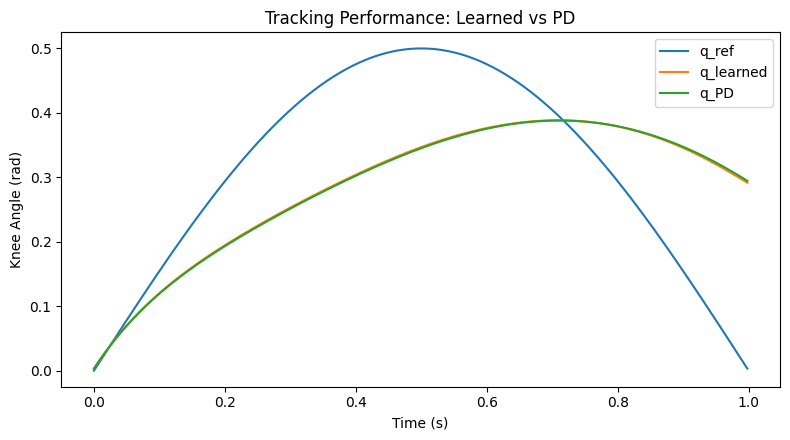

[publication] finished tracking_comparison
[publication] starting tracking_error
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\tracking_error.png


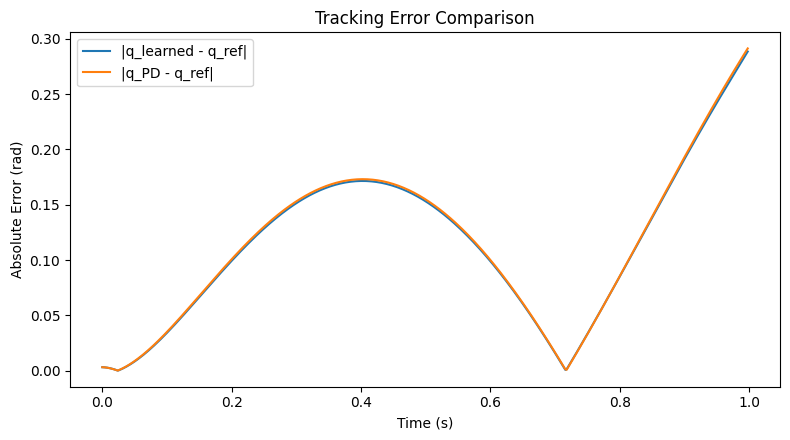

[publication] finished tracking_error
[publication] starting peak_timing_analysis
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\peak_timing_analysis.png


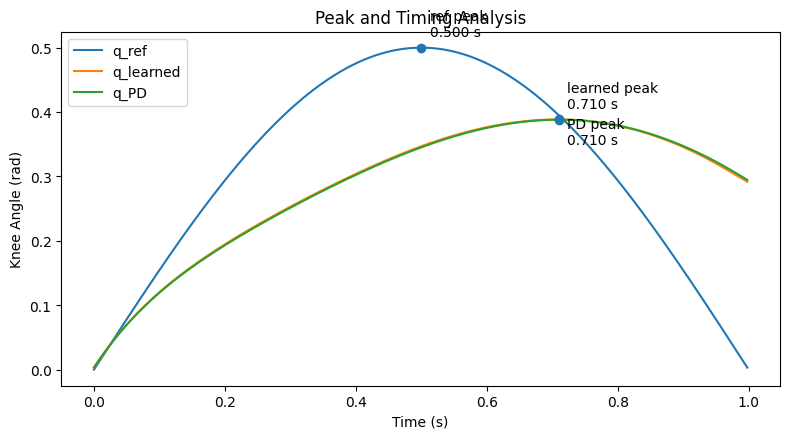

[publication] finished peak_timing_analysis
[publication] starting torque_comparison
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\torque_comparison.png


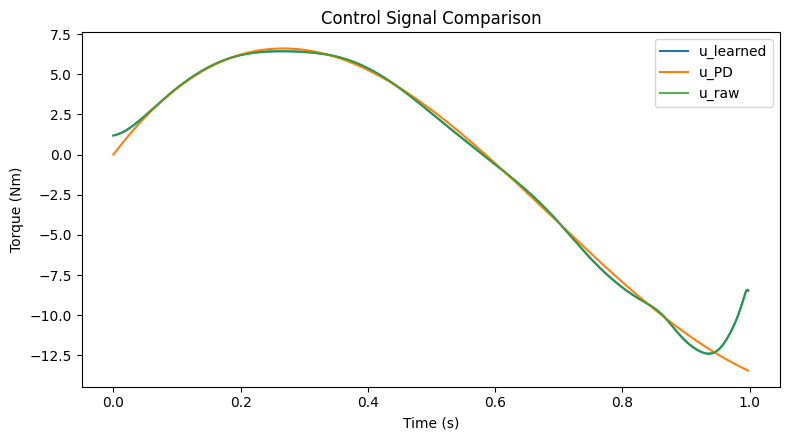

[publication] finished torque_comparison
[publication] starting control_energy
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\control_energy.png


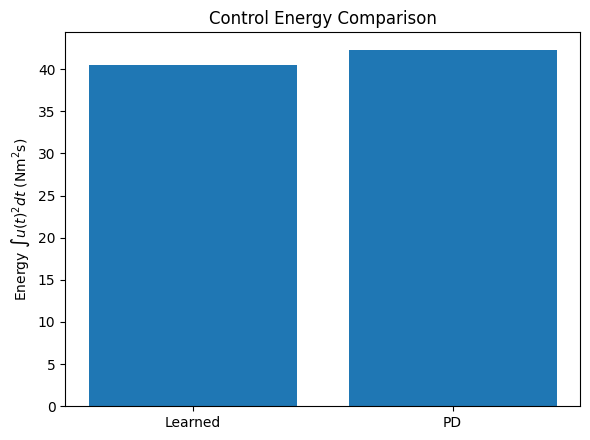

[publication] finished control_energy
[publication] starting phase_portrait
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\phase_portrait.png


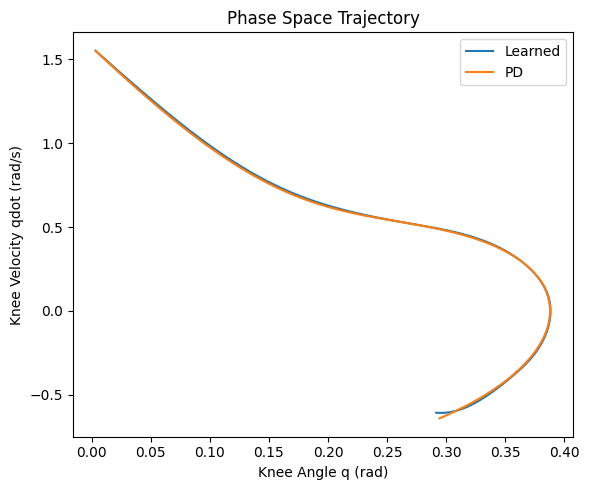

[publication] finished phase_portrait
[publication] starting learned_policy_field
[publication] finished learned_policy_field
[publication] starting pd_policy_field
[publication] finished pd_policy_field
[publication] starting save_policy_field
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\policy_field.png


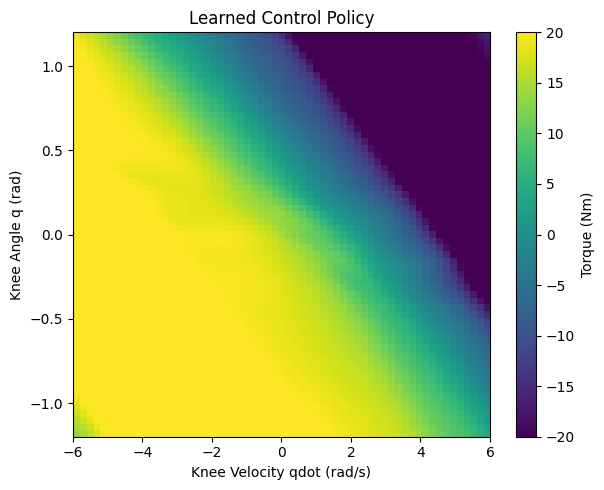

[publication] finished save_policy_field
[publication] starting save_pd_policy_field
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\pd_policy_field.png


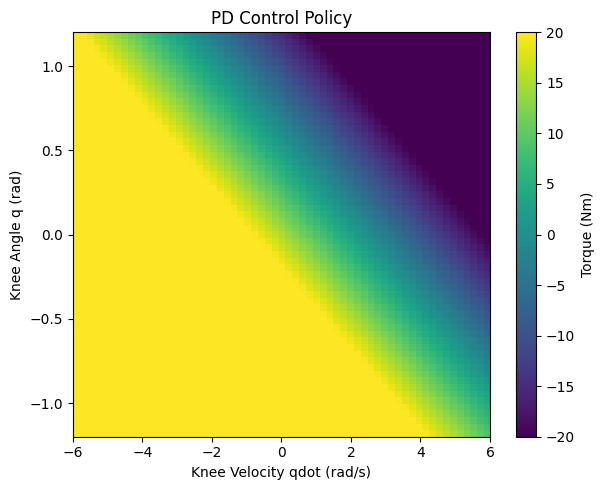

[publication] finished save_pd_policy_field
[publication] starting save_policy_difference
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\policy_difference.png


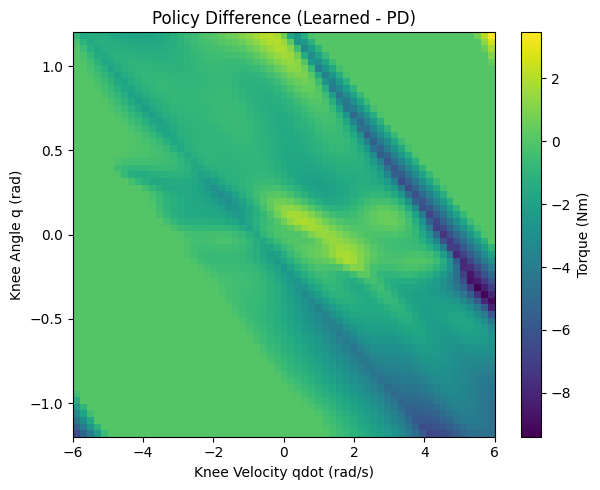

[publication] finished save_policy_difference
[publication] starting generalization_tracking
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\generalization_tracking.png


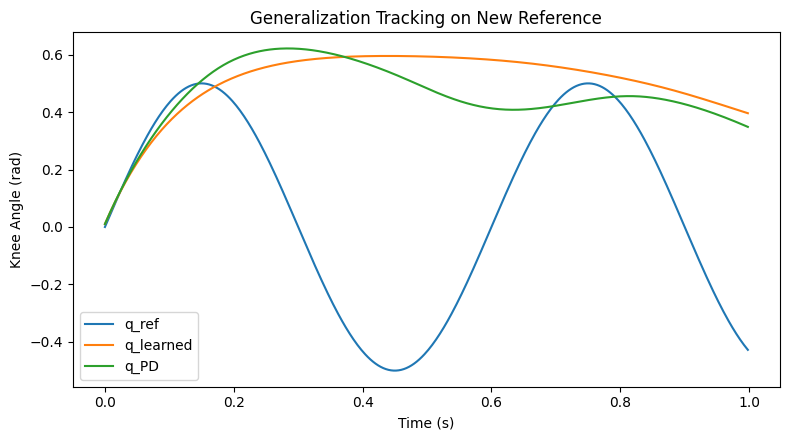

[publication] finished generalization_tracking
[publication] starting export_summary_table
Saved table CSV: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\controller_summary.csv
| Method | RMSE | Peak Error | Time-to-Peak | Energy | Torque Corr |
|---|---:|---:|---:|---:|---:|
| Learned | 0.1332 | 0.1114 | 0.7100 | 40.5093 | 0.9947 |
| PD | 0.1346 | 0.1119 | 0.7100 | 42.2571 | 1.0000 |
Saved table Markdown: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\controller_summary.md
[publication] finished export_summary_table
[publication] starting loss_curves
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\loss_curves.png


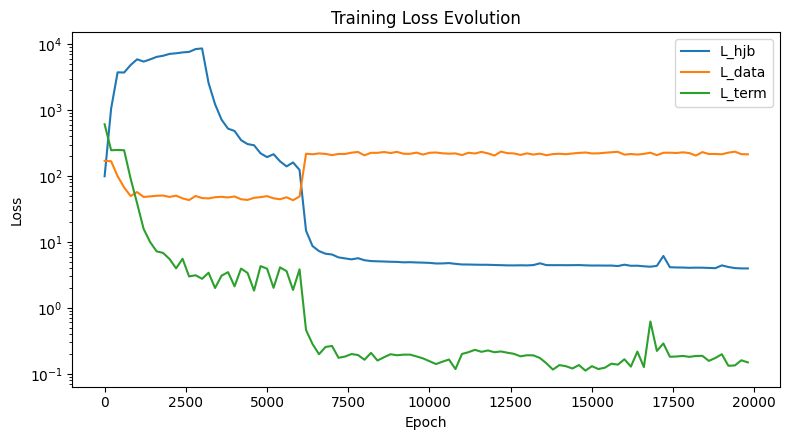

[publication] finished loss_curves
[publication] starting run_ablations
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering full at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0414 omega=1.3202 control=0.0000
[data debug] q min/max -0.07673990726470947 1.2991641759872437
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -23.779390335083008 7.215547561645508
[data debug] u min/max -41.58419418334961 56.08097457885742
[data debug] t min/max 0.0 1.0
epoch 0 | phase=full q[-1.200,1.200] qd[-6.000,5.999] u_raw[-0.014,0.031] u_bounded[-0.014,0.031] ctrl_sig[-0.016,0.007] sat_ratio 0.000 grad_ema 404.532 L_hjb 98.8691 L_term 629.2649 L_data 175.9353 L_rollout 0.0049 L_u_match 145.0966 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:02<13:10:29,  2.37s/it]

[rollout-check] epoch 0 RMSE=0.1783


...

epoch 19600 | phase=full q[-1.200,1.200] qd[-6.000,5.999] u_raw[-163.364,89.048] u_bounded[-20.000,20.000] ctrl_sig[-46.902,86.044] sat_ratio 0.470 grad_ema 523.664 L_hjb 4.5896 L_term 0.1588 L_data 212.5778 L_rollout 0.0035 L_u_match 8.5869 L_sat 280.8649


Training pure_hjb:  99%|█████████▉| 19801/20000 [1:54:01<01:11,  2.77it/s]

epoch 19800 | phase=full q[-1.200,1.200] qd[-6.000,5.999] u_raw[-162.269,90.816] u_bounded[-20.000,20.000] ctrl_sig[-47.833,85.467] sat_ratio 0.469 grad_ema 502.375 L_hjb 5.4005 L_term 0.1822 L_data 223.0361 L_rollout 0.0027 L_u_match 8.4970 L_sat 280.2208


Training pure_hjb: 100%|██████████| 20000/20000 [1:55:11<00:00,  2.89it/s]

[train_bounds] train_observed_u_raw_range [-172.342, 107.807]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-56.782, 90.773]


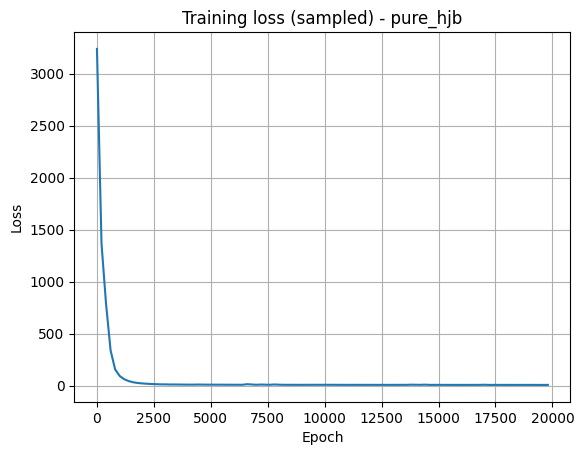

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0496 omega=1.3112 control=0.0001
[data debug] q min/max -0.07761377841234207 1.2749543190002441
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -33.67128372192383 7.134259223937988
[data debug] u min/max -44.19557189941406 39.917442321777344
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-5.997,5.999] u_raw[0.039,0.091] u_bounded[0.039,0.091] ctrl_sig[-0.048,-0.020] sat_ratio 0.000 grad_ema 353.369 L_hjb 97.9809 L_term 612.4789 L_data 180.8248 L_rollout 0.0050 L_u_match 146.6791 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:03<16:51:35,  3.03s/it]

[rollout-check] epoch 0 RMSE=0.1766


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-5.997,5.999] u_raw[-396.551,159.398] u_bounded[-20.000,20.000] ctrl_sig[-83.955,208.864] sat_ratio 0.534 grad_ema 404.176 L_hjb 9635.7256 L_term 0.0509 L_data 218.1363 L_rollout 0.0045 L_u_match 1.9156 L_sat 438.4054


Training pure_hjb:  99%|█████████▉| 19801/20000 [2:01:13<01:08,  2.91it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-5.997,5.999] u_raw[-397.635,160.166] u_bounded[-20.000,20.000] ctrl_sig[-84.360,209.435] sat_ratio 0.534 grad_ema 401.546 L_hjb 9665.7842 L_term 0.0529 L_data 216.9988 L_rollout 0.0029 L_u_match 1.8988 L_sat 439.8389


Training pure_hjb: 100%|██████████| 20000/20000 [2:02:23<00:00,  2.72it/s]

[train_bounds] train_observed_u_raw_range [-407.585, 161.510]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-85.068, 214.675]


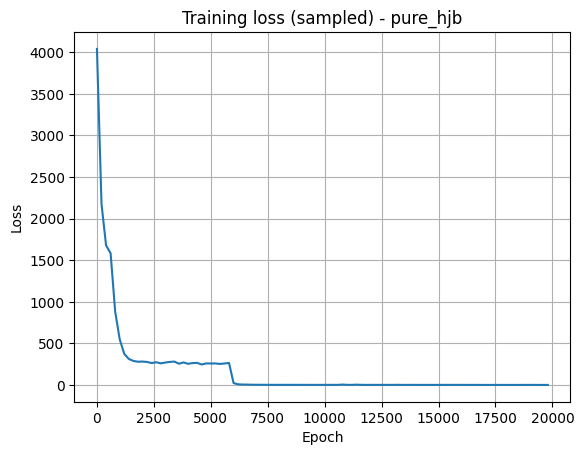

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt
[params] I=2.1946 B=14.5638 m=1.0000 g=9.81 l=0.0241 u_max=20.00
[params] w_u=0.020000 control_mult=1.139e+01 capped=False mult_used=1.139e+01
[scales] q_scale=1.2000 qd_scale=6.0000
[sanity] q0=0.2, qd0=0.0
[sanity] ?q(+u), ?qd(+u) = 0.00584055483341217 0.048054181039333344
[sanity] ?q(-u), ?qd(-u) = -0.0064154863357543945 -0.05278386175632477
[sanity] sign check ok: +u increases q, -u decreases q
[sanity] PD micro-test stable on 0.1 rad sinusoid
TRAIN/ROLLOUT CONSISTENCY CHECK
  dt=0.002 horizon=1.0 time_normalized=False T_phys=1.0
  u_max=20.0 sat_method=clamp ref_type=synthetic


Training pure_hjb:   0%|          | 0/20000 [00:00<?, ?it/s]

[schedule] entering stage_A at epoch 0
[objective] running_cost = w_track*(q-theta_ref)^2 + w_omega*(qd-omega_ref)^2 + w_u*(u_used)^2
[objective] w_track=10.0000 w_omega=0.1000 w_u=0.0200 use_u_bounded_in_residual=True
[objective] mean terms track=6.0397 omega=1.3164 control=0.0000
[data debug] q min/max -0.10236065834760666 1.2552435398101807
[data debug] q_ref min/max -4.371138828673793e-08 0.5
[data debug] qd min/max -7.578823089599609 9.675939559936523
[data debug] u min/max -48.31050109863281 40.46831130981445
[data debug] t min/max 0.0 1.0
epoch 0 | phase=stage_A q[-1.200,1.200] qd[-6.000,6.000] u_raw[-0.052,0.057] u_bounded[-0.052,0.057] ctrl_sig[-0.030,0.027] sat_ratio 0.000 grad_ema 423.213 L_hjb 98.8544 L_term 639.6354 L_data 173.2664 L_rollout 0.0060 L_u_match 148.9404 L_sat 0.0000


Training pure_hjb:   0%|          | 1/20000 [00:03<17:09:06,  3.09s/it]

[rollout-check] epoch 0 RMSE=0.1774


...

epoch 19600 | phase=stage_C q[-1.200,1.200] qd[-6.000,6.000] u_raw[-168.853,90.592] u_bounded[-20.000,20.000] ctrl_sig[-47.715,88.935] sat_ratio 0.468 grad_ema 488.197 L_hjb 5.4973 L_term 0.1350 L_data 221.9571 L_rollout 0.0031 L_u_match 7.4146 L_sat 285.0861


Training pure_hjb:  99%|█████████▉| 19801/20000 [2:00:06<01:09,  2.87it/s]

epoch 19800 | phase=stage_C q[-1.200,1.200] qd[-6.000,6.000] u_raw[-170.454,92.968] u_bounded[-20.000,20.000] ctrl_sig[-48.967,89.778] sat_ratio 0.465 grad_ema 440.859 L_hjb 4.5882 L_term 0.1037 L_data 221.6441 L_rollout 0.0032 L_u_match 7.3647 L_sat 283.7929


Training pure_hjb: 100%|██████████| 20000/20000 [2:01:16<00:00,  2.75it/s]

[train_bounds] train_observed_u_raw_range [-229.135, 95.936]
[train_bounds] train_observed_u_bounded_range [-20.000, 20.000]
[train_bounds] train_observed_control_signal_range [-50.529, 120.686]


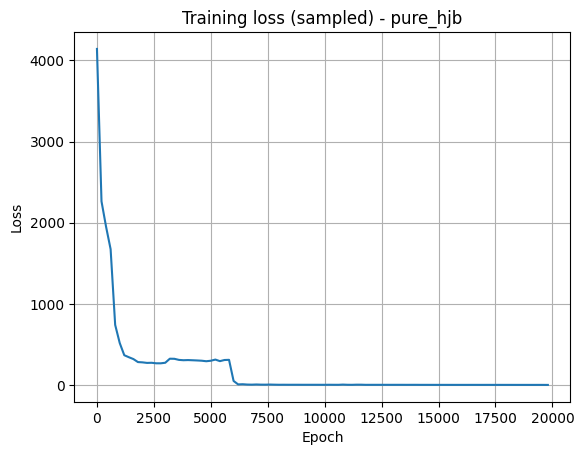

Saved checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee_pure_hjb.pt
Updated latest checkpoint: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\checkpoints\hjb_pinn_knee.pt
[publication] finished run_ablations
[publication] starting ablation_tracking
Saved figure: e:\Optimal_Control\PINN\hjb_pinn_exoskeleton\results\figures\ablation_tracking.png


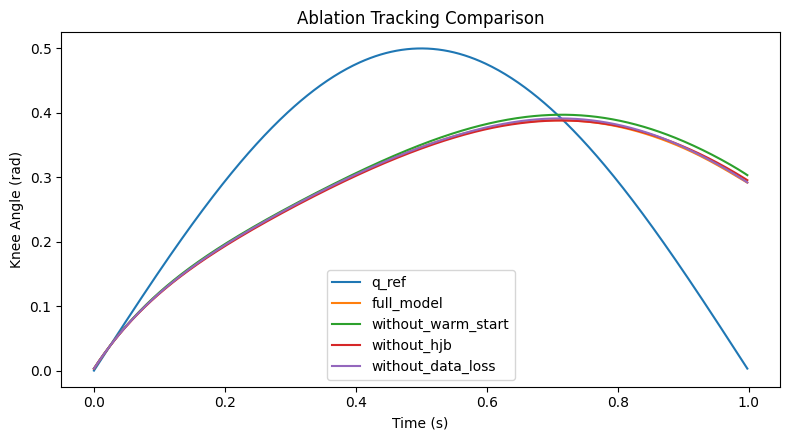

[publication] finished ablation_tracking


In [32]:
if RUN_PUBLICATION_RESULTS:
    print(f"[publication] results directory: {RESULTS_DIR}")
    active_net, active_cfg, active_residual, active_hist = get_active_artifacts()
    publication_bundle = run_publication_step(
        "rollout_bundle",
        rollout_bundle,
        active_net,
        active_cfg,
        active_residual,
        T_local=PUBLICATION_T,
    )

    run_publication_step("tracking_comparison", save_tracking_comparison, publication_bundle, "tracking_comparison.png")
    run_publication_step("tracking_error", save_tracking_error, publication_bundle, "tracking_error.png")
    run_publication_step("peak_timing_analysis", save_peak_timing_analysis, publication_bundle, "peak_timing_analysis.png")
    run_publication_step("torque_comparison", save_torque_comparison, publication_bundle, "torque_comparison.png")
    run_publication_step("control_energy", save_control_energy, publication_bundle, "control_energy.png")
    run_publication_step("phase_portrait", save_phase_portrait, publication_bundle, "phase_portrait.png")

    q_vals, qd_vals, u_field, u_raw_field = run_publication_step(
        "learned_policy_field",
        policy_field,
        active_cfg,
        active_net,
        active_residual,
        t_value=0.5,
        n=61,
    )
    q_vals_pd, qd_vals_pd, u_pd_field = run_publication_step(
        "pd_policy_field",
        pd_policy_field,
        active_cfg,
        t_value=0.5,
        n=61,
    )
    run_publication_step("save_policy_field", save_policy_field, q_vals, qd_vals, u_field, "Learned Control Policy", "policy_field.png")
    run_publication_step("save_pd_policy_field", save_policy_field, q_vals_pd, qd_vals_pd, u_pd_field, "PD Control Policy", "pd_policy_field.png")
    run_publication_step("save_policy_difference", save_policy_field, q_vals, qd_vals, u_field - u_pd_field, "Policy Difference (Learned - PD)", "policy_difference.png")

    generalization_bundle = run_publication_step(
        "generalization_tracking",
        save_generalization_tracking,
        active_net,
        active_cfg,
        active_residual,
        "generalization_tracking.png",
    )
    summary_rows = run_publication_step("export_summary_table", export_summary_table, publication_bundle, "controller_summary.csv", "controller_summary.md")
    run_publication_step("loss_curves", save_loss_curves, active_hist, "loss_curves.png")

    if RUN_ABLATIONS:
        ablation_bundles = run_publication_step("run_ablations", run_ablation_bundles, PUBLICATION_STAGE, active_cfg)
        run_publication_step("ablation_tracking", save_ablation_tracking, publication_bundle, ablation_bundles, "ablation_tracking.png")
    else:
        print("Set RUN_ABLATIONS = True to retrain the ablation models and save ablation_tracking.png")
else:
    print("Set RUN_PUBLICATION_RESULTS = True to generate the publication-quality figures.")
